# Fashion MNIST - CNN Classification

### Dataset

* Fashion MNIST is a benchmark image classification dataset containing **70,000 grayscale images**.
* Each image is **28 × 28 pixels** and belongs to **one of 10 clothing categories**.
* The dataset is divided into **60,000 training images** and **10,000 testing images**.

### Model

* A **Convolutional Neural Network (CNN)** is used to automatically learn image features and classify clothing items.
* The model consists of convolution, pooling, and fully connected layers, and is trained using the Fashion MNIST dataset.


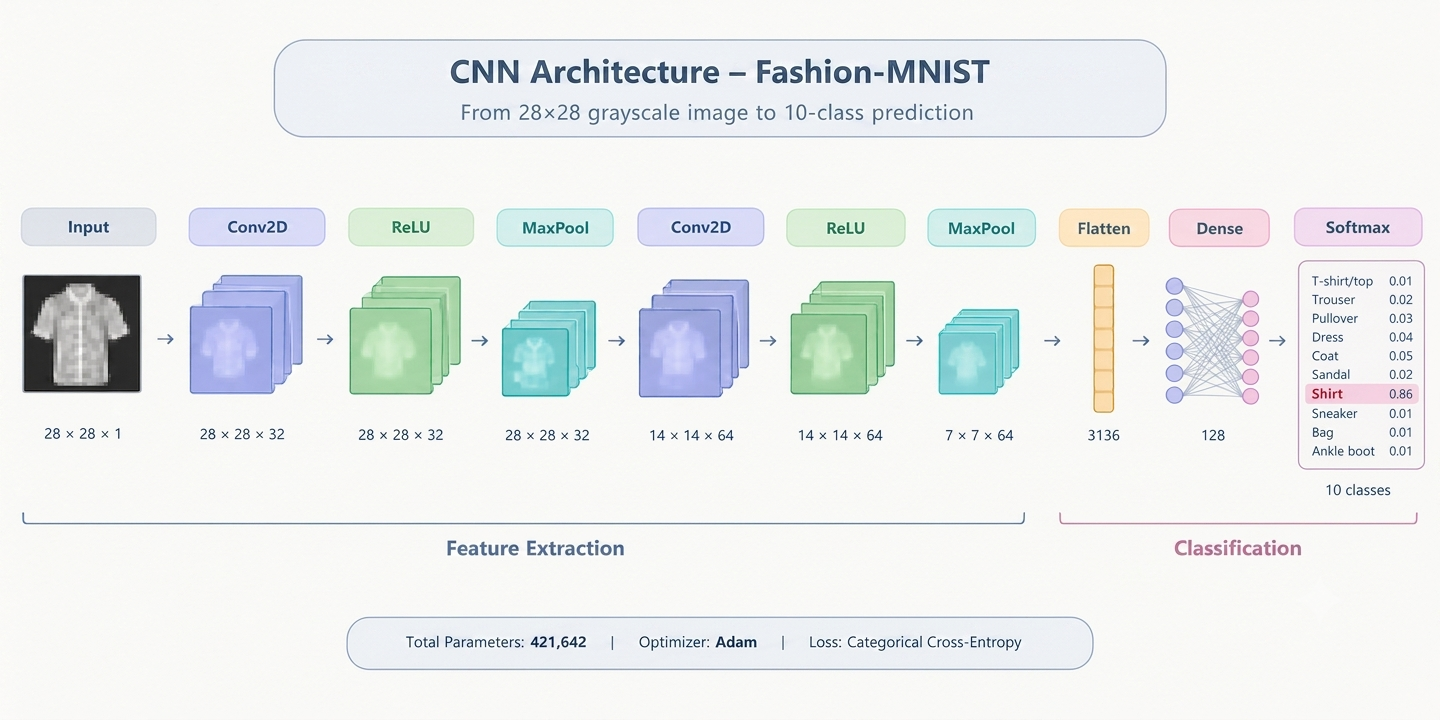

## Task 1: Imports and Configuration



In [1]:
%pip install -q tensorflow scikit-learn matplotlib seaborn pandas

In [2]:
import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, initializers, optimizers

from sklearn.metrics import confusion_matrix, classification_report

sns.set_style("whitegrid")
plt.rcParams["figure.facecolor"] = "white"

SEED = 42
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


This section imports all the required libraries, sets the random seed for reproducibility, and configures the notebook environment for the experiments.

##Task 2: Load Fashion MNIST


In [3]:
CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

print("Full training set:", x_train_full.shape, y_train_full.shape)
print("Test set:         ", x_test.shape, y_test.shape)
print("Pixel value range:", x_train_full.min(), "to", x_train_full.max())
print("Pixel dtype:", x_train_full.dtype)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Full training set: (60000, 28, 28) (60000,)
Test set:          (10000, 28, 28) (10000,)
Pixel value range: 0 to 255
Pixel dtype: uint8


70,000 grayscale 28x28 images across 10 clothing categories: 60,000 for train, 10,000 for test. We carve a validation set out of the training set so the test set stays untouched until the very end.

## **Train–Validation Data Split**

In [4]:
# Carve out a validation set (stratified by class) from the training data
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full,
    test_size=0.1,
    stratify=y_train_full,
    random_state=SEED,
)

print("Train:", x_train.shape, " Val:", x_val.shape, " Test:", x_test.shape)

counts = pd.Series(y_train).value_counts().sort_index()
counts.index = CLASS_NAMES
display(counts.rename("train_count").to_frame())

Train: (54000, 28, 28)  Val: (6000, 28, 28)  Test: (10000, 28, 28)


,train_count
T-shirt/top,5400
Trouser,5400
Pullover,5400
Dress,5400
Coat,5400
Sandal,5400
Shirt,5400
Sneaker,5400
Bag,5400
Ankle boot,5400


## Task 3: Exploratory Data Analysis

VISUALIZING THE DATASET

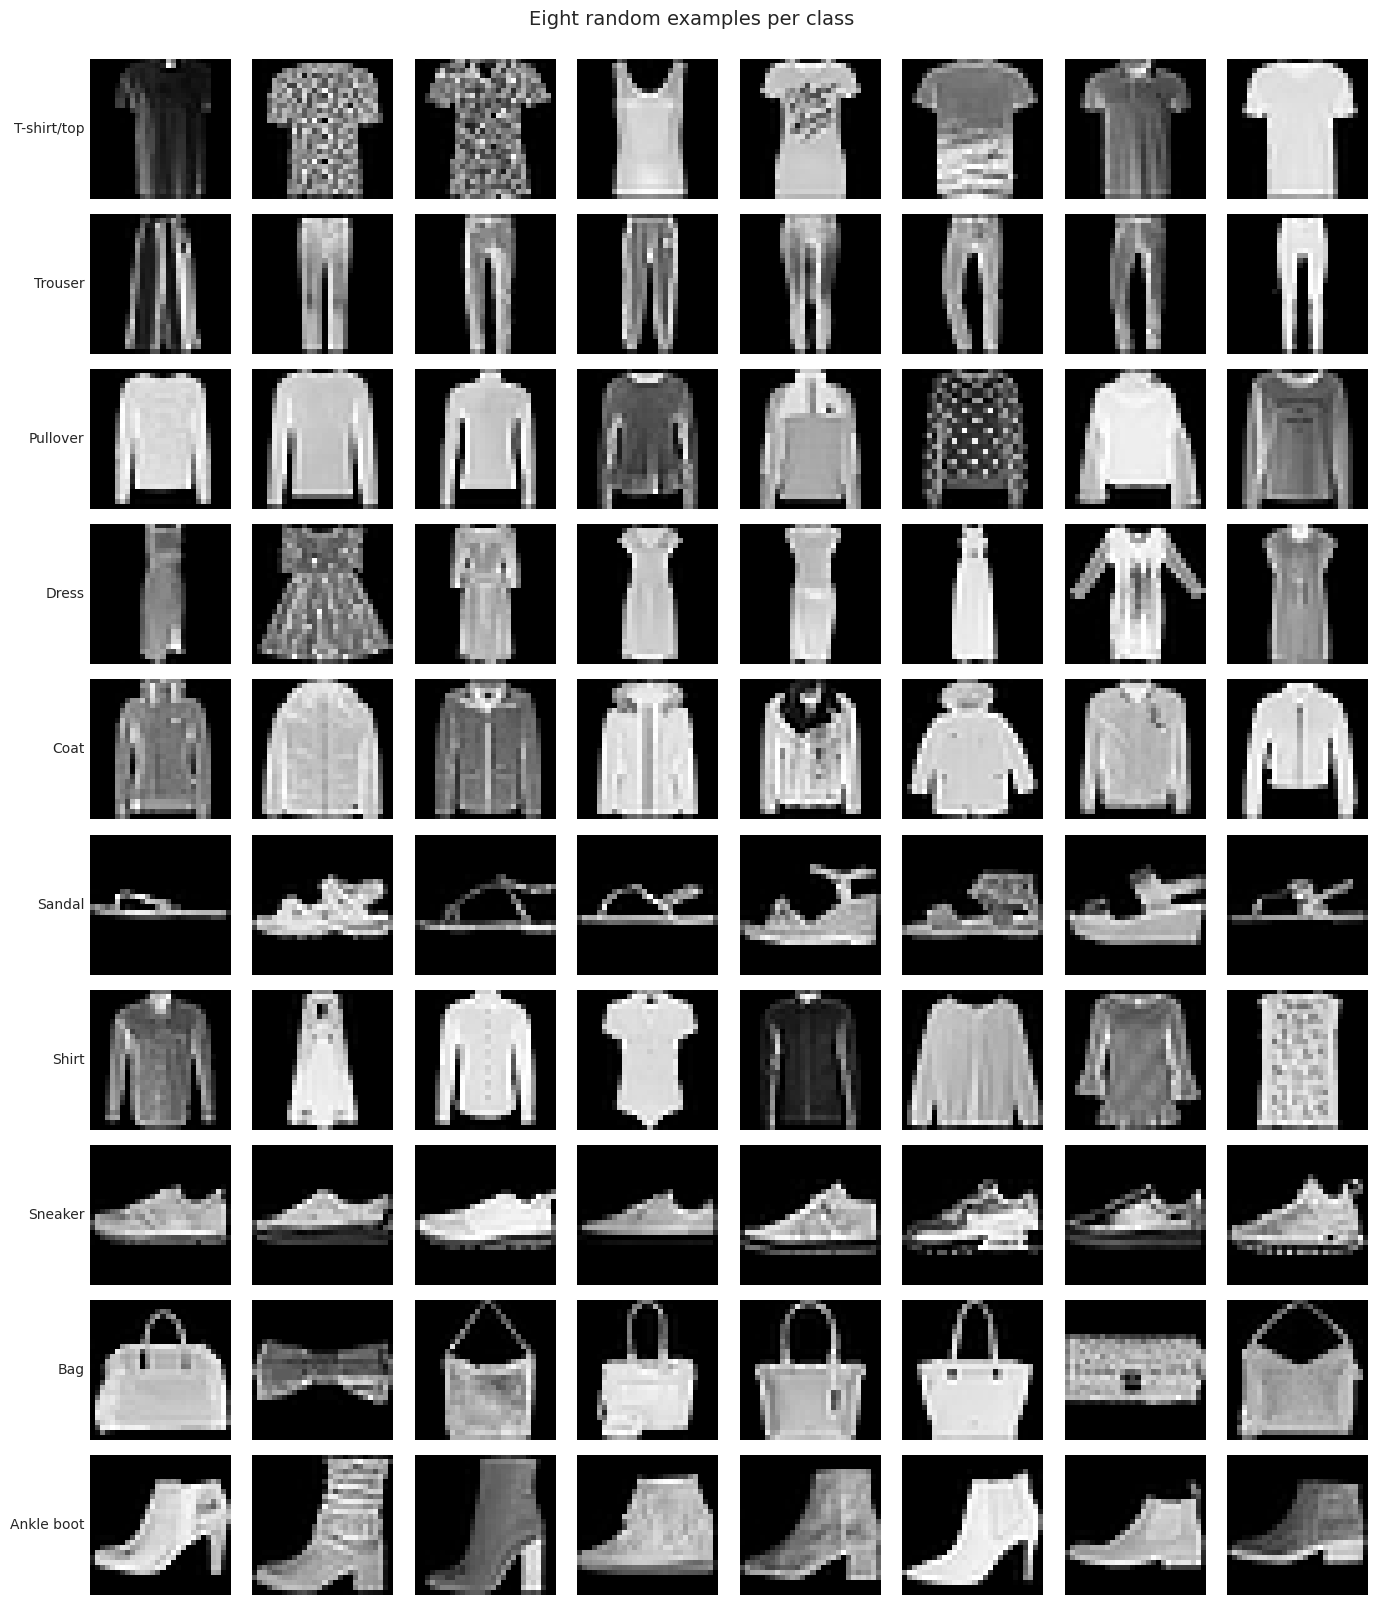

In [5]:
fig, axes = plt.subplots(10, 8, figsize=(14, 16))
rng = np.random.default_rng(SEED)

for class_idx in range(10):
    class_positions = np.where(y_train == class_idx)[0]
    chosen = rng.choice(class_positions, size=8, replace=False)
    for col, idx in enumerate(chosen):
        ax = axes[class_idx, col]
        ax.imshow(x_train[idx], cmap="gray")
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(CLASS_NAMES[class_idx], rotation=0, ha="right", va="center", fontsize=10)
            ax.axis("on")
            ax.set_xticks([]); ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)

fig.suptitle("Eight random examples per class", y=1.0, fontsize=14)
plt.tight_layout()
plt.show()

This section displays random sample images from each of the 10 Fashion MNIST classes. Visualizing the dataset helps verify the class labels, understand the appearance of each clothing category, and inspect the images before preprocessing and model training.

CLASS DISTRIBUTION AND RAW PIXEL INTENSITY DISTRIBUTION

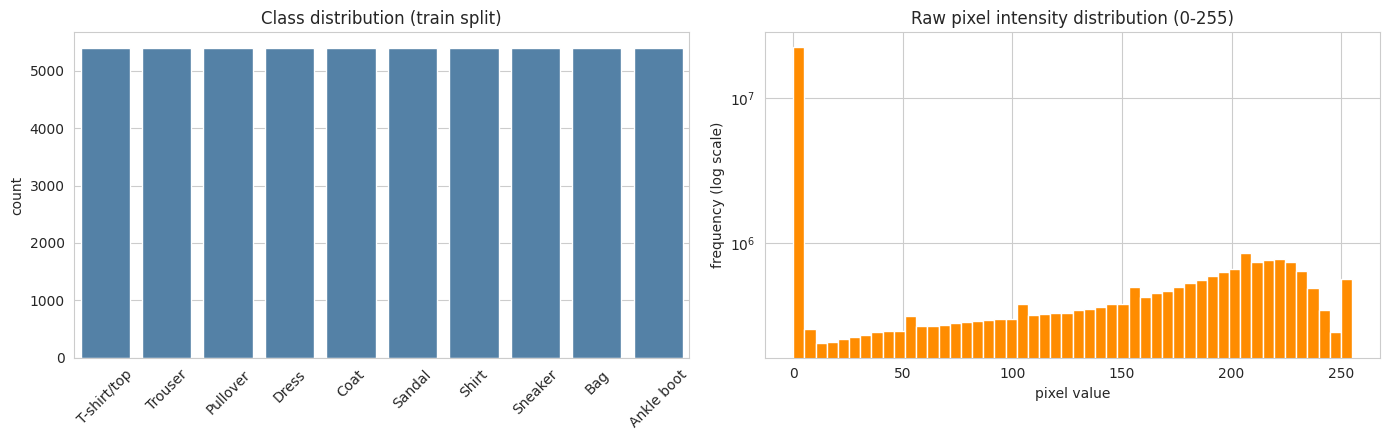

Notice the two spikes: a huge one near 0 (black background) and a smaller one near 255
(bright garment edges/highlights). Most of the image is 'nothing' — this is why CNNs,
which exploit local spatial structure, work so much better here than a flat pixel vector.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.countplot(x=[CLASS_NAMES[i] for i in y_train], order=CLASS_NAMES, ax=axes[0], color="steelblue")
axes[0].set_title("Class distribution (train split)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_ylabel("count")

axes[1].hist(x_train.ravel(), bins=50, color="darkorange")
axes[1].set_title("Raw pixel intensity distribution (0-255)")
axes[1].set_xlabel("pixel value")
axes[1].set_ylabel("frequency (log scale)")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

print("Notice the two spikes: a huge one near 0 (black background) and a smaller one near 255")
print("(bright garment edges/highlights). Most of the image is 'nothing' — this is why CNNs,")
print("which exploit local spatial structure, work so much better here than a flat pixel vector.")

##Preprocessing



In [7]:
def preprocess_images(images):
    images = images.astype("float32") / 255.0
    images = np.expand_dims(images, axis=-1)  # (N, 28, 28) -> (N, 28, 28, 1)
    return images

x_train_p = preprocess_images(x_train)
x_val_p = preprocess_images(x_val)
x_test_p = preprocess_images(x_test)

y_train_oh = keras.utils.to_categorical(y_train, 10)
y_val_oh = keras.utils.to_categorical(y_val, 10)
y_test_oh = keras.utils.to_categorical(y_test, 10)

print("Shapes after preprocessing:")
print("  x_train:", x_train_p.shape, x_train_p.dtype)
print("  y_train (one-hot):", y_train_oh.shape)
print()
print("Example label -> one-hot: ", y_train[0], "->", y_train_oh[0])

Shapes after preprocessing:
  x_train: (54000, 28, 28, 1) float32
  y_train (one-hot): (54000, 10)

Example label -> one-hot:  8 -> [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]


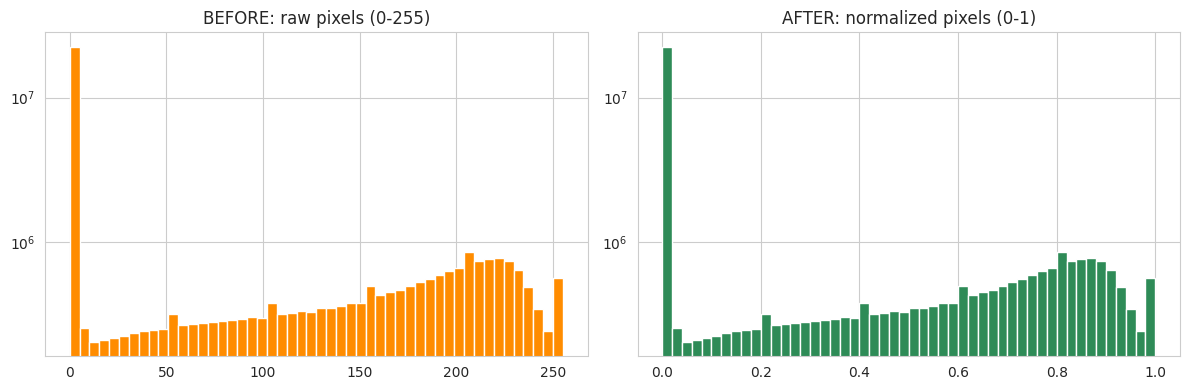

Same distribution shape, just rescaled — this is exactly the point: normalization
changes the SCALE gradients operate on, not the information content of the image.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(x_train.ravel(), bins=50, color="darkorange")
axes[0].set_title("BEFORE: raw pixels (0-255)")
axes[0].set_yscale("log")

axes[1].hist(x_train_p.ravel(), bins=50, color="seagreen")
axes[1].set_title("AFTER: normalized pixels (0-1)")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()
print("Same distribution shape, just rescaled — this is exactly the point: normalization")
print("changes the SCALE gradients operate on, not the information content of the image.")

1. **Normalize to [0, 1]** by dividing by 255. Neural nets train far more reliably on small,
   zero-centered-ish inputs — large raw pixel values (up to 255) make gradients and weight updates
   unstable, especially combined with certain activations (we'll see this concretely in the
   activation-function experiment later).
2. **Add a channel dimension**: `(28, 28) -> (28, 28, 1)`. `Conv2D` always expects a channel axis,
   even for grayscale.
3. **One-hot encode labels** for categorical cross-entropy, e.g. class `3` -> `[0,0,0,1,0,0,0,0,0,0]`.


## Task 4. Build the CNN


**Architecture:**

```
Input (28,28,1)
 -> Conv2D(filters1, 3x3) -> [BatchNorm] -> Activation -> MaxPool(2x2)
 -> Conv2D(filters2, 3x3) -> [BatchNorm] -> Activation -> MaxPool(2x2)
 -> Flatten
 -> Dense(128) -> Activation -> [Dropout]
 -> Dense(10, softmax)
```


In [9]:
def build_cnn(
    activation="relu",
    kernel_initializer="he_normal",
    use_batchnorm=False,
    dropout_rate=0.0,
    filters=(32, 64),
    dense_units=128,
    learning_rate=1e-3,
    name="cnn",
):
    inputs = keras.Input(shape=(28, 28, 1), name="input_image")

    x = layers.Conv2D(filters[0], (3, 3), padding="same",
                       kernel_initializer=kernel_initializer, name="conv1")(inputs)
    if use_batchnorm:
        x = layers.BatchNormalization(name="bn1")(x)
    x = layers.Activation(activation, name="act1")(x)
    x = layers.MaxPooling2D((2, 2), name="pool1")(x)  # 28x28 -> 14x14

    x = layers.Conv2D(filters[1], (3, 3), padding="same",
                       kernel_initializer=kernel_initializer, name="conv2")(x)
    if use_batchnorm:
        x = layers.BatchNormalization(name="bn2")(x)
    x = layers.Activation(activation, name="act2")(x)
    x = layers.MaxPooling2D((2, 2), name="pool2")(x)  # 14x14 -> 7x7

    x = layers.Flatten(name="flatten")(x)
    x = layers.Dense(dense_units, kernel_initializer=kernel_initializer, name="dense1")(x)
    x = layers.Activation(activation, name="act3")(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate, name="dropout")(x)

    outputs = layers.Dense(10, activation="softmax",
                            kernel_initializer=kernel_initializer, name="predictions")(x)

    model = keras.Model(inputs, outputs, name=name)
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

baseline_model = build_cnn(name="baseline_cnn")
baseline_model.summary()
initial_weights = baseline_model.get_layer("conv1").get_weights()[0].copy()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act1 (Activation)               │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act2 (Activation)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act3 (Activation)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

Build a Convolutional Neural Network (CNN) by stacking convolution, activation, pooling, flatten, and dense layers. This section defines the model architecture, learning parameters, and prepares it for training and evaluation.

### Visualize the architecture as a diagram
`28x28x1 -> 28x28x32 -> 14x14x32 -> 14x14x64 -> 7x7x64 -> flatten(3136) -> 128 -> 10`.


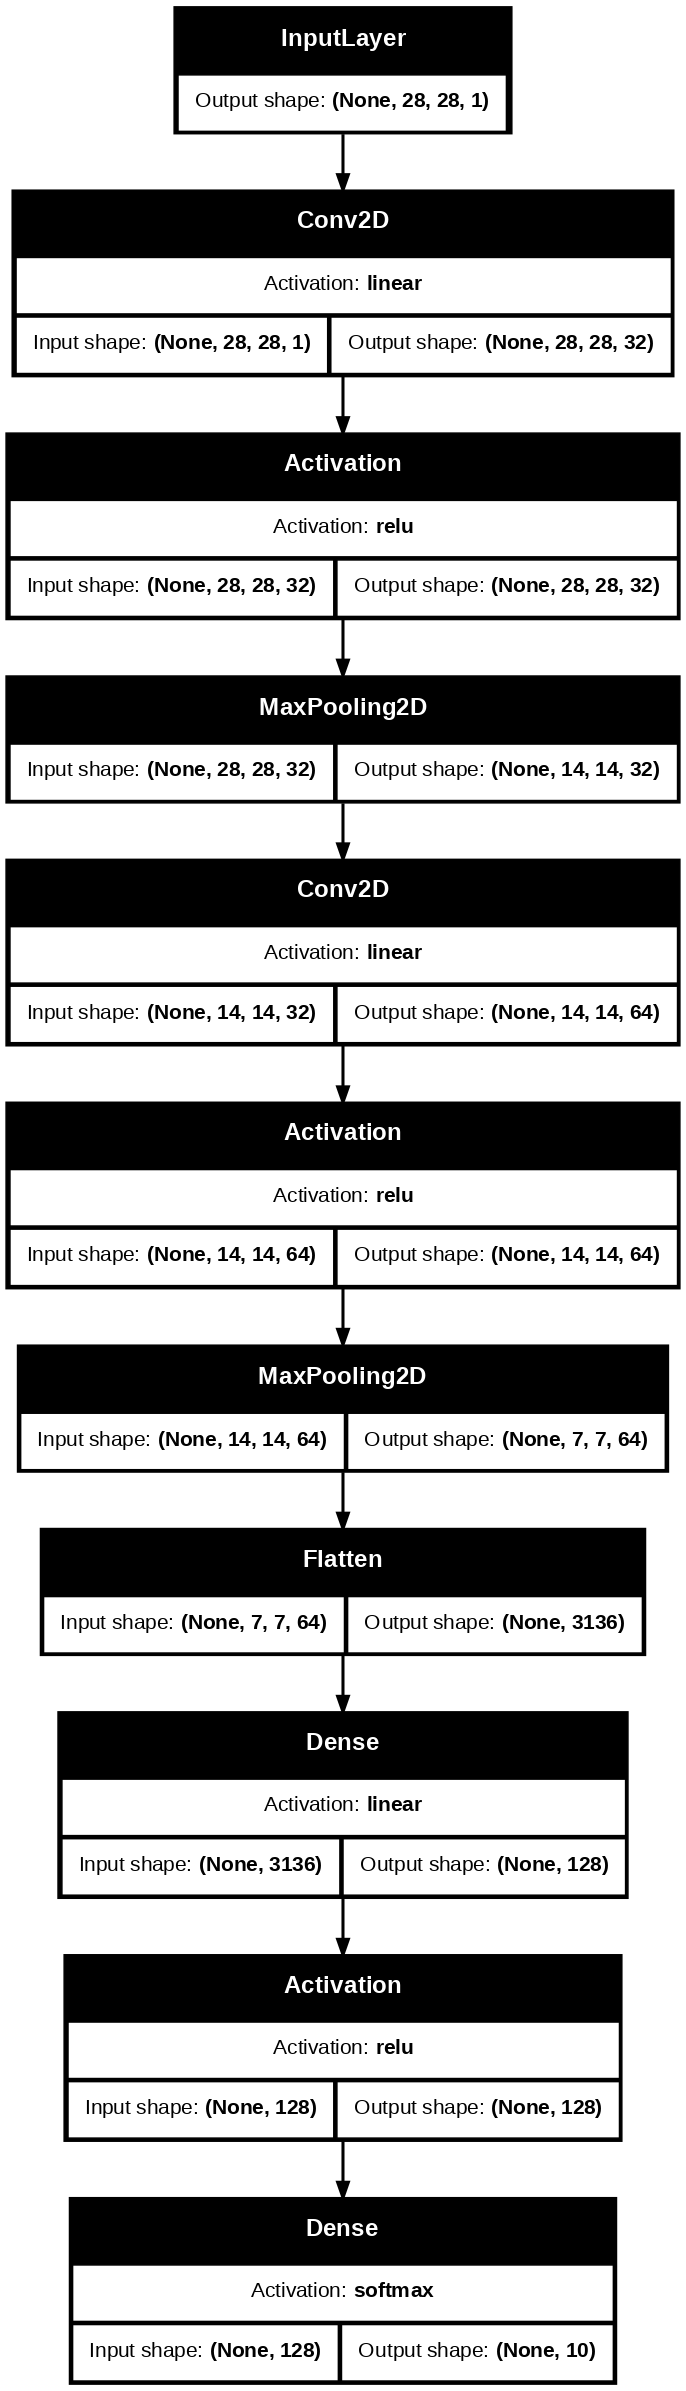

In [10]:
keras.utils.plot_model(
    baseline_model,
    to_file="architecture.png",
    show_shapes=True,
    show_layer_activations=True,
    dpi=110,
)
from IPython.display import Image as IPyImage
IPyImage("architecture.png")

## Visualizing Convolution Filters Before Training

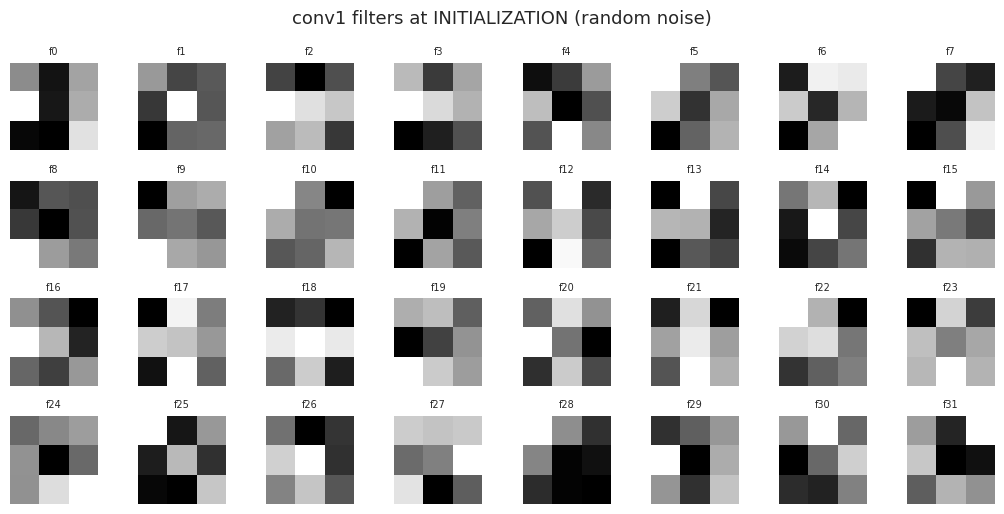


Conv1 - Filter 0 weights BEFORE training:
[[-0.25283593 -0.75786656 -0.15182823]
 [ 0.23038778 -0.74278826 -0.12022295]
 [-0.8101472  -0.8412857   0.10248667]]


In [11]:
def plot_conv_filters(model, layer_name, title, max_filters=32):
    layer = model.get_layer(layer_name)
    weights = layer.get_weights()[0]  # (kh, kw, in_channels, out_channels)
    n_filters = min(max_filters, weights.shape[-1])

    cols = 8
    rows = int(np.ceil(n_filters / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.3, rows * 1.3))
    axes = np.array(axes).reshape(rows, cols)

    for i in range(rows * cols):
        ax = axes[i // cols, i % cols]
        ax.axis("off")
        if i < n_filters:
            kernel = weights[:, :, 0, i]  # first input channel
            ax.imshow(kernel, cmap="gray")
            ax.set_title(f"f{i}", fontsize=7)

    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

plot_conv_filters(baseline_model, "conv1", "conv1 filters at INITIALIZATION (random noise)")
print("\nConv1 - Filter 0 weights BEFORE training:")
print(initial_weights[:, :, 0, 0])

Visualize the first convolutional layer's filters immediately after model initialization. At this stage, the filters contain randomly initialized weights and have not yet learned any meaningful features from the training images.

## Visualizing Feature Maps (Untrained conv1 layers)

Sample image true class: Shirt


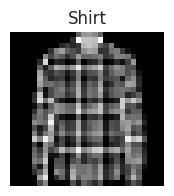

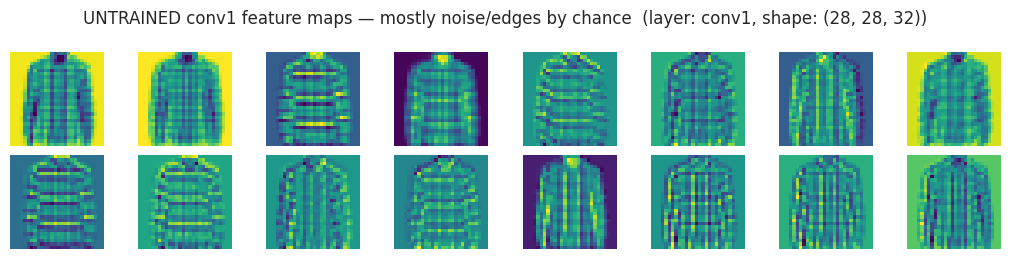

In [12]:
def get_activation_model(model, layer_names):
    outputs = [model.get_layer(name).output for name in layer_names]
    return keras.Model(inputs=model.input, outputs=outputs)

def plot_feature_maps(activations, layer_name, title, max_maps=16):
    n_maps = min(max_maps, activations.shape[-1])
    cols = 8
    rows = int(np.ceil(n_maps / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.3, rows * 1.3))
    axes = np.array(axes).reshape(rows, cols)

    for i in range(rows * cols):
        ax = axes[i // cols, i % cols]
        ax.axis("off")
        if i < n_maps:
            ax.imshow(activations[0, :, :, i], cmap="viridis")

    fig.suptitle(f"{title}  (layer: {layer_name}, shape: {activations.shape[1:]})", fontsize=12)
    plt.tight_layout()
    plt.show()

sample_idx = 7
sample_image = x_test_p[sample_idx:sample_idx + 1]
print("Sample image true class:", CLASS_NAMES[y_test[sample_idx]])
plt.figure(figsize=(2, 2))
plt.imshow(sample_image[0, :, :, 0], cmap="gray")
plt.title(CLASS_NAMES[y_test[sample_idx]])
plt.axis("off")
plt.show()

conv_layer_names = ["conv1", "pool1", "conv2", "pool2"]
act_model = get_activation_model(baseline_model, conv_layer_names)
untrained_activations = act_model.predict(sample_image, verbose=0)

plot_feature_maps(untrained_activations[0], "conv1", "UNTRAINED conv1 feature maps — mostly noise/edges by chance")

Generate and visualize the feature maps (activations) produced by the convolutional layers. This helps understand what visual patterns the CNN detects at different stages before and after training.

## Task 6: Train the baseline model


In [13]:
# Quick epoch x batch-size search (9 combos) on a 15k stratified subset, using the SAME
# plain architecture the baseline uses (no BatchNorm/Dropout) — just to pick good EPOCHS/BATCH_SIZE
from sklearn.model_selection import train_test_split

x_search, _, y_search, _ = train_test_split(
    x_train, y_train, train_size=15000, stratify=y_train, random_state=SEED
)
x_search_p = preprocess_images(x_search)
y_search_oh = keras.utils.to_categorical(y_search, 10)

epoch_cases = [15, 20, 25]
batch_cases = [64, 128, 256]
ebs_results = {}

for ep in epoch_cases:
    ebs_results[ep] = {}
    for bs in batch_cases:
        tf.random.set_seed(SEED)
        model = build_cnn(name=f"search_ep{ep}_bs{bs}")
        cb = [
            keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
        ]
        start = time.time()
        hist = model.fit(
            x_search_p, y_search_oh,
            validation_data=(x_val_p, y_val_oh),
            epochs=ep, batch_size=bs,
            callbacks=cb, verbose=0,
        )
        elapsed = time.time() - start
        ebs_results[ep][bs] = (model, hist, elapsed)
        print(f"epochs={ep}, batch_size={bs}: best val_acc={max(hist.history['val_accuracy']):.4f}, "
              f"ran {len(hist.history['loss'])} epochs in {elapsed:.1f}s")

epochs=15, batch_size=64: best val_acc=0.9112, ran 12 epochs in 28.4s
epochs=15, batch_size=128: best val_acc=0.9127, ran 15 epochs in 17.9s
epochs=15, batch_size=256: best val_acc=0.9048, ran 15 epochs in 15.9s
epochs=20, batch_size=64: best val_acc=0.9090, ran 12 epochs in 24.8s
epochs=20, batch_size=128: best val_acc=0.9053, ran 13 epochs in 15.3s
epochs=20, batch_size=256: best val_acc=0.9102, ran 20 epochs in 16.5s
epochs=25, batch_size=64: best val_acc=0.9097, ran 11 epochs in 22.0s
epochs=25, batch_size=128: best val_acc=0.9098, ran 12 epochs in 14.1s
epochs=25, batch_size=256: best val_acc=0.9102, ran 23 epochs in 21.3s


**EPOCHS X BATCH SIZE COMBINATIONS**

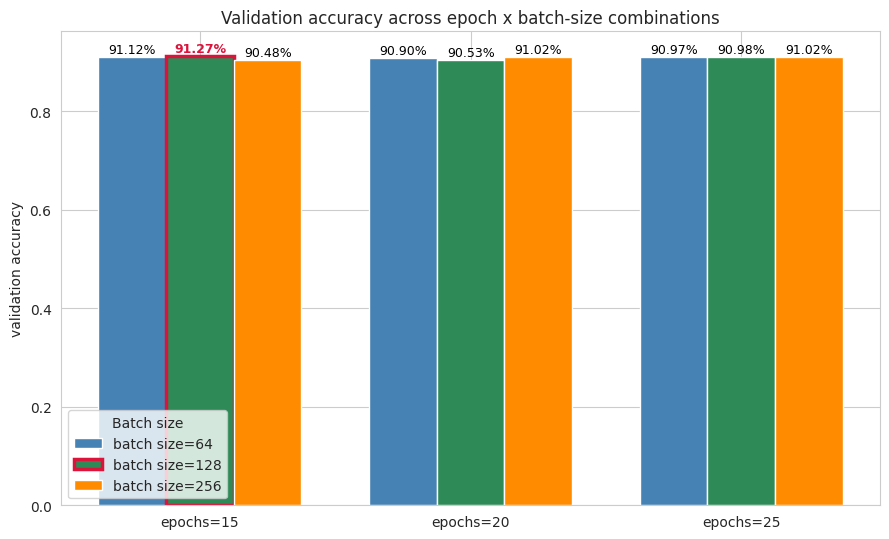

Winning combination: epochs=15, batch_size=128 (val_accuracy=0.9127)
These EPOCHS / BATCH_SIZE values will be used to train the real baseline model below.


In [14]:
# Visualize all 9 combinations as a grouped bar chart (epochs x batch_size -> val accuracy)
bar_width = 0.25
colors = {64: "steelblue", 128: "seagreen", 256: "darkorange"}

fig, ax = plt.subplots(figsize=(9, 5.5))

best_acc = -1
best_ep, best_bs = None, None
for ep in epoch_cases:
    for bs in batch_cases:
        _, hist, _ = ebs_results[ep][bs]
        acc = max(hist.history["val_accuracy"])
        if acc > best_acc:
            best_acc, best_ep, best_bs = acc, ep, bs

x = np.arange(len(epoch_cases))  # one group per epoch setting

for i, bs in enumerate(batch_cases):
    accs = [max(ebs_results[ep][bs][1].history["val_accuracy"]) for ep in epoch_cases]
    offsets = x + (i - 1) * bar_width
    bars = ax.bar(offsets, accs, width=bar_width, label=f"batch size={bs}", color=colors[bs])

    for bar, ep, acc in zip(bars, epoch_cases, accs):
        is_best = (ep == best_ep and bs == best_bs)
        if is_best:
            bar.set_edgecolor("crimson")
            bar.set_linewidth(2.5)
        ax.text(bar.get_x() + bar.get_width() / 2, acc + 0.002, f"{acc:.2%}",
                ha="center", va="bottom", fontsize=9,
                fontweight="bold" if is_best else "normal",
                color="crimson" if is_best else "black")

ax.set_xticks(x)
ax.set_xticklabels([f"epochs={ep}" for ep in epoch_cases])
ax.set_ylabel("validation accuracy")
ax.set_title("Validation accuracy across epoch x batch-size combinations")
ax.set_ylim(0, max(acc for ep in epoch_cases for bs in batch_cases
                    for acc in [max(ebs_results[ep][bs][1].history["val_accuracy"])]) + 0.05)
ax.legend(title="Batch size")
plt.tight_layout()
plt.show()

EPOCHS = int(best_ep)
BATCH_SIZE = int(best_bs)
print(f"Winning combination: epochs={EPOCHS}, batch_size={BATCH_SIZE} (val_accuracy={best_acc:.4f})")
print("These EPOCHS / BATCH_SIZE values will be used to train the real baseline model below.")

In [15]:
EPOCHS = int(best_ep)
BATCH_SIZE = int(best_bs)

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
]

start = time.time()
history = baseline_model.fit(
    x_train_p, y_train_oh,
    validation_data=(x_val_p, y_val_oh),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=2,
)
print(f"Training took {time.time() - start:.1f}s, {len(history.history['loss'])} epochs run")

Epoch 1/15
422/422 - 4s - 10ms/step - accuracy: 0.8452 - loss: 0.4325 - val_accuracy: 0.8875 - val_loss: 0.3128 - learning_rate: 0.0010
Epoch 2/15
422/422 - 3s - 8ms/step - accuracy: 0.8956 - loss: 0.2885 - val_accuracy: 0.9058 - val_loss: 0.2582 - learning_rate: 0.0010
Epoch 3/15
422/422 - 3s - 8ms/step - accuracy: 0.9123 - loss: 0.2421 - val_accuracy: 0.9095 - val_loss: 0.2438 - learning_rate: 0.0010
Epoch 4/15
422/422 - 3s - 7ms/step - accuracy: 0.9236 - loss: 0.2113 - val_accuracy: 0.9118 - val_loss: 0.2354 - learning_rate: 0.0010
Epoch 5/15
422/422 - 3s - 7ms/step - accuracy: 0.9329 - loss: 0.1871 - val_accuracy: 0.9150 - val_loss: 0.2356 - learning_rate: 0.0010
Epoch 6/15
422/422 - 3s - 8ms/step - accuracy: 0.9405 - loss: 0.1656 - val_accuracy: 0.9093 - val_loss: 0.2511 - learning_rate: 0.0010
Epoch 7/15
422/422 - 3s - 8ms/step - accuracy: 0.9491 - loss: 0.1383 - val_accuracy: 0.9198 - val_loss: 0.2284 - learning_rate: 5.0000e-04
Epoch 8/15
422/422 - 5s - 11ms/step - accuracy: 0.

Train the baseline CNN using the preprocessed Fashion MNIST dataset. The model is optimized with the Adam optimizer, categorical cross-entropy loss, and monitored using validation data. Early Stopping and ReduceLROnPlateau callbacks are used to prevent overfitting and automatically adjust the learning rate during training.

PLOT LOSS AND ACCURACY

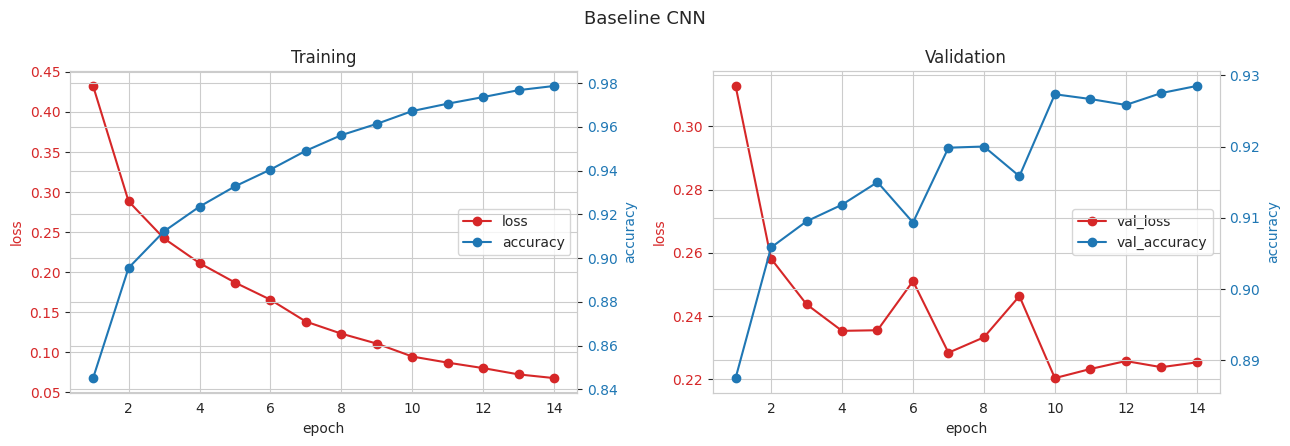

Test accuracy: 0.9179   Test loss: 0.2558


In [16]:
def plot_history(history, title="Training history"):
    hist = history.history
    epochs_range = range(1, len(hist["loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    # Left panel: training loss + training accuracy together
    ax1 = axes[0]
    l1, = ax1.plot(epochs_range, hist["loss"], "o-", color="tab:red", label="loss")
    ax1.set_xlabel("epoch")
    ax1.set_ylabel("loss", color="tab:red")
    ax1.tick_params(axis="y", labelcolor="tab:red")
    ax1.set_title("Training")

    ax1b = ax1.twinx()
    l2, = ax1b.plot(epochs_range, hist["accuracy"], "o-", color="tab:blue", label="accuracy")
    ax1b.set_ylabel("accuracy", color="tab:blue")
    ax1b.tick_params(axis="y", labelcolor="tab:blue")
    ax1.legend(handles=[l1, l2], loc="center right")

    # Right panel: validation loss + validation accuracy together
    ax2 = axes[1]
    l3, = ax2.plot(epochs_range, hist["val_loss"], "o-", color="tab:red", label="val_loss")
    ax2.set_xlabel("epoch")
    ax2.set_ylabel("loss", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")
    ax2.set_title("Validation")

    ax2b = ax2.twinx()
    l4, = ax2b.plot(epochs_range, hist["val_accuracy"], "o-", color="tab:blue", label="val_accuracy")
    ax2b.set_ylabel("accuracy", color="tab:blue")
    ax2b.tick_params(axis="y", labelcolor="tab:blue")
    ax2.legend(handles=[l3, l4], loc="center right")

    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

plot_history(history, "Baseline CNN")

test_loss, test_acc = baseline_model.evaluate(x_test_p, y_test_oh, verbose=0)
print(f"Test accuracy: {test_acc:.4f}   Test loss: {test_loss:.4f}")

✅ Training loss consistently decreased, showing the CNN learned useful patterns.

✅ Validation loss decreased until about Epoch 5, indicating good generalization.

✅ After Epoch 5, validation performance stopped improving while training performance continued improving, showing mild overfitting.

✅ EarlyStopping prevented unnecessary training and restored the best-performing weights.

✅ The final test accuracy of 91.79% confirms that the CNN performs well on completely unseen Fashion MNIST images.

##Filters after training



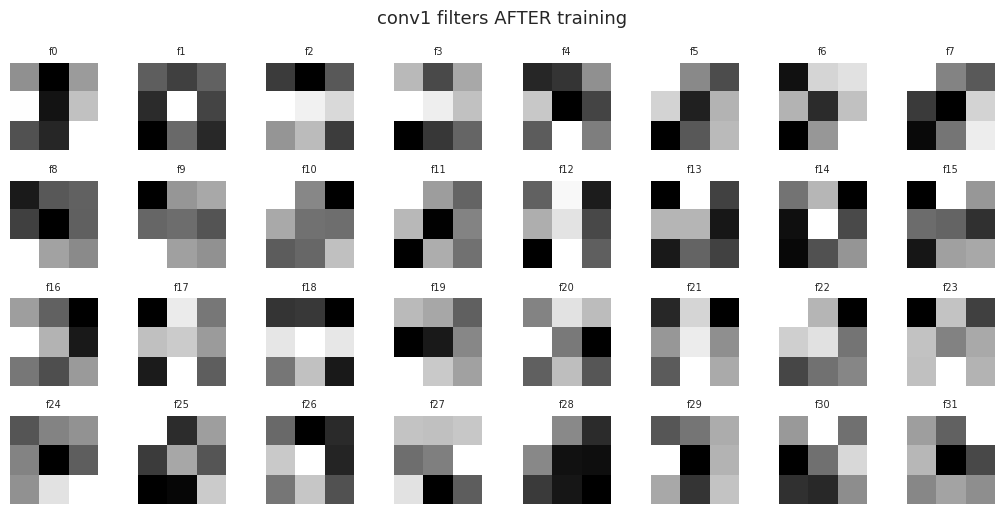


Conv1 - Filter 0 weights AFTER training:
[[-0.26351118 -1.1649652  -0.19462861]
 [ 0.41940802 -1.0431062   0.03945714]
 [-0.64850205 -0.9239004   0.43115187]]


In [17]:
plot_conv_filters(baseline_model, "conv1", "conv1 filters AFTER training")
trained_weights = baseline_model.get_layer("conv1").get_weights()[0]

# Print Filter 0 weights
print("\nConv1 - Filter 0 weights AFTER training:")
print(trained_weights[:, :, 0, 0])

"3×3 filters are too small for random-vs-trained differences to be visually obvious, and imshow auto-rescales each filter's own min→max range, masking real weight-magnitude changes. The learning is real,it's just not visible at this filter size and display method, not stalled training."

**COMPARISION BETWEEN TRAINED CONV1 AND CONV2 FEATURE MAPS**

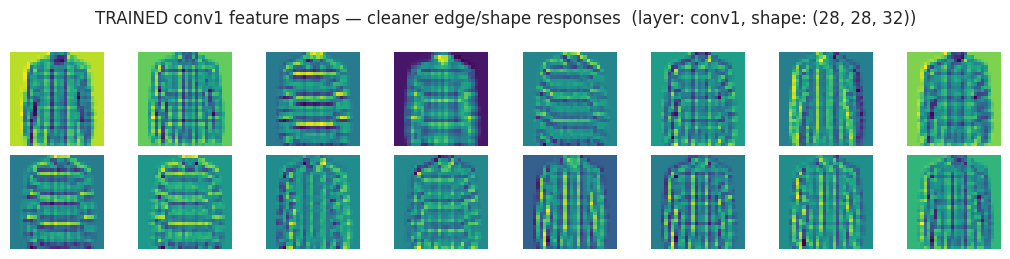

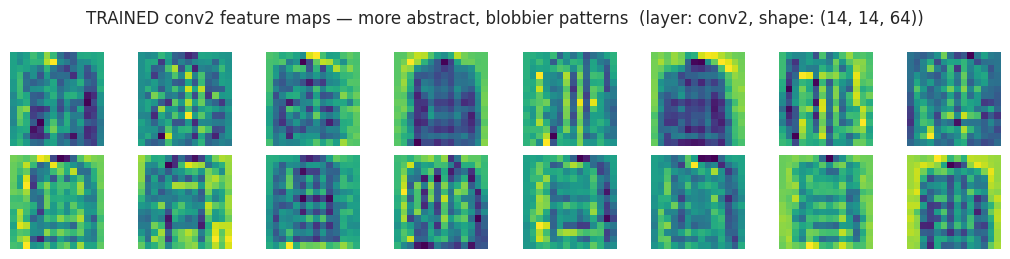

In [18]:
trained_activations = act_model.predict(sample_image, verbose=0)
plot_feature_maps(trained_activations[0], "conv1",
                   "TRAINED conv1 feature maps — cleaner edge/shape responses")
plot_feature_maps(trained_activations[2], "conv2",
                   "TRAINED conv2 feature maps — more abstract, blobbier patterns")

The trained CNN feature maps show how the network detects edges, shapes, textures, and higher-level patterns from the input image.

### Feature maps across the whole network for one image, layer by layer



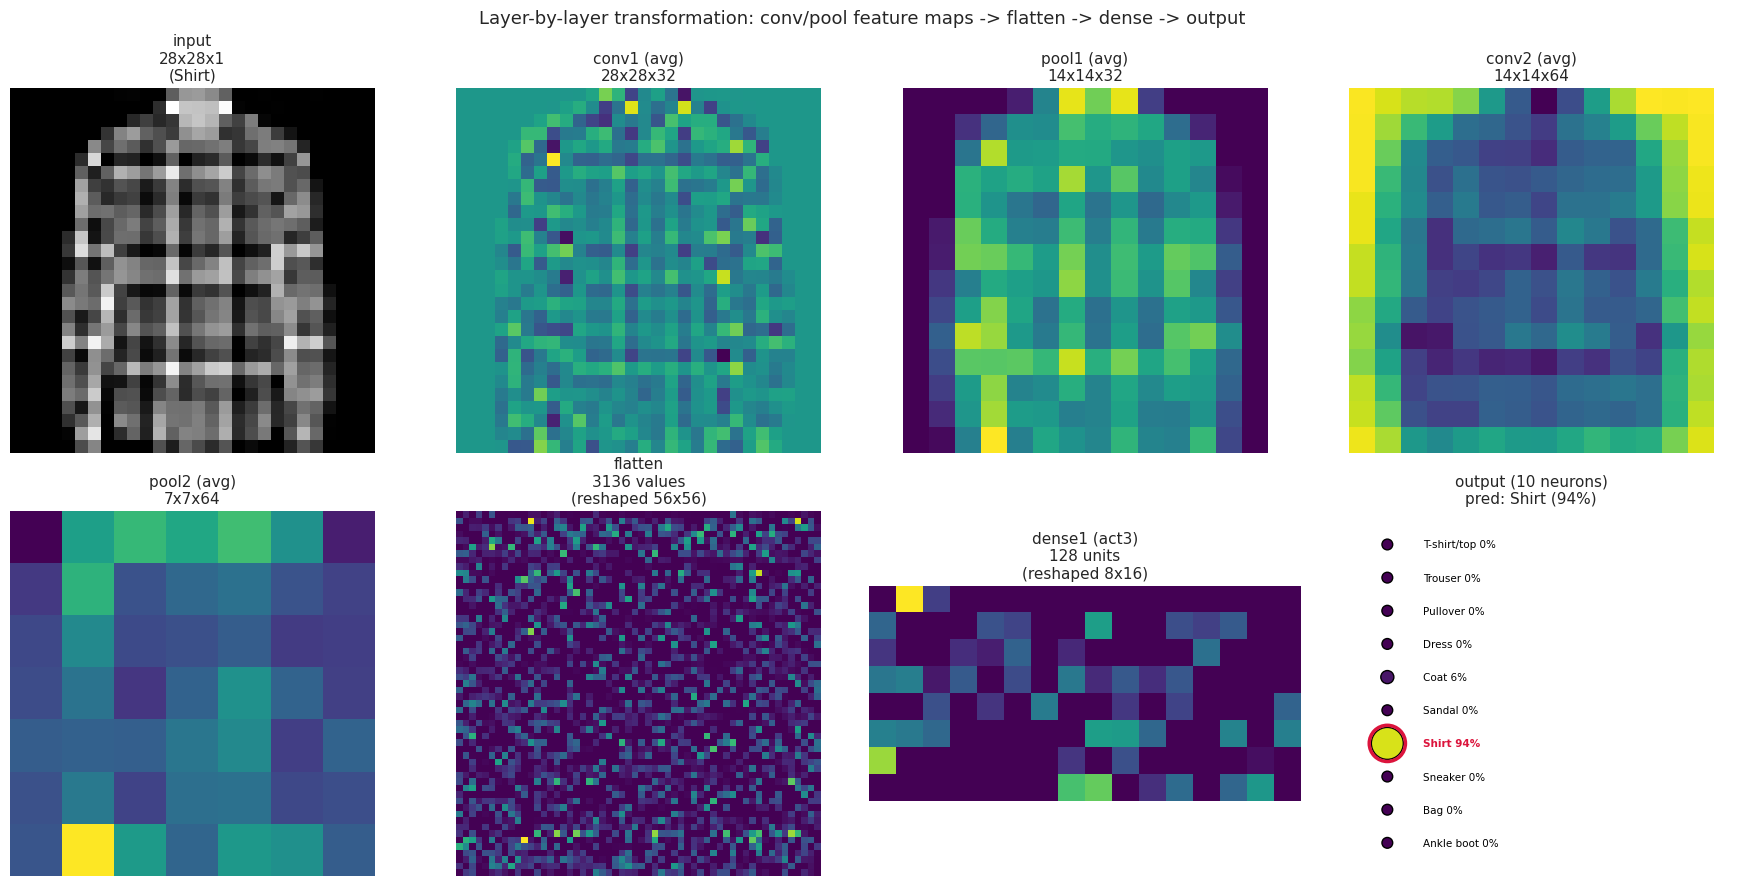

Shape journey: 28x28x1 -> 28x28x32 -> 14x14x32 -> 14x14x64 -> 7x7x64 -> flatten(3136) -> dense(128) -> output(10)
Final decision: Shirt with 94.1% confidence


In [19]:
# Layer-by-layer transformation: 4 layers in row 1, 3 + output-neurons in row 2
full_layer_names = ["conv1", "pool1", "conv2", "pool2", "flatten", "act3", "predictions"]
full_act_model = get_activation_model(baseline_model, full_layer_names)
full_activations = full_act_model.predict(sample_image, verbose=0)

conv1_a, pool1_a, conv2_a, pool2_a, flatten_a, dense_a, pred_a = full_activations

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

# Row 1: input, conv1, pool1, conv2
axes[0, 0].imshow(sample_image[0, :, :, 0], cmap="gray")
axes[0, 0].set_title(f"input\n28x28x1\n({CLASS_NAMES[y_test[sample_idx]]})", fontsize=11)
axes[0, 0].axis("off")

row1_maps = [conv1_a, pool1_a, conv2_a]
row1_titles = ["conv1 (avg)\n28x28x32", "pool1 (avg)\n14x14x32", "conv2 (avg)\n14x14x64"]
for i, (act, title) in enumerate(zip(row1_maps, row1_titles)):
    avg_map = act[0].mean(axis=-1)
    axes[0, i + 1].imshow(avg_map, cmap="viridis")
    axes[0, i + 1].set_title(title, fontsize=11)
    axes[0, i + 1].axis("off")

# Row 2: pool2, flatten, dense1, output-neurons
pool2_avg = pool2_a[0].mean(axis=-1)
axes[1, 0].imshow(pool2_avg, cmap="viridis")
axes[1, 0].set_title("pool2 (avg)\n7x7x64", fontsize=11)
axes[1, 0].axis("off")

flat_vec = flatten_a[0]
side = int(np.sqrt(flat_vec.shape[0]))          # 56
flat_grid = flat_vec[:side*side].reshape(side, side)
axes[1, 1].imshow(flat_grid, cmap="viridis")
axes[1, 1].set_title(f"flatten\n{flat_vec.shape[0]} values\n(reshaped {side}x{side})", fontsize=11)
axes[1, 1].axis("off")

dense_vec = dense_a[0]
dense_grid = dense_vec.reshape(8, 16)
axes[1, 2].imshow(dense_grid, cmap="viridis")
axes[1, 2].set_title(f"dense1 (act3)\n{dense_vec.shape[0]} units\n(reshaped 8x16)", fontsize=11)
axes[1, 2].axis("off")

# Output layer as small neuron diagram, in the same figure/grid
probs = pred_a[0]
pred_class = np.argmax(probs)
ax_out = axes[1, 3]

y_positions = np.arange(10)   # stack vertically since the panel is small/square
x_position = np.zeros(10)

sizes = 60 + probs * 500       # smaller circles to fit a small panel
scatter = ax_out.scatter(x_position, y_positions, s=sizes, c=probs, cmap="viridis",
                          vmin=0, vmax=1, edgecolors="black", linewidths=1, zorder=3)
ax_out.scatter(x_position[pred_class], y_positions[pred_class], s=sizes[pred_class] + 150,
               facecolors="none", edgecolors="crimson", linewidths=2.5, zorder=4)

for i in range(10):
    ax_out.text(0.25, y_positions[i], f"{CLASS_NAMES[i]} {probs[i]:.0%}",
                fontsize=7.5, va="center",
                fontweight="bold" if i == pred_class else "normal",
                color="crimson" if i == pred_class else "black")

ax_out.set_xlim(-0.5, 2.5)
ax_out.set_ylim(-1, 10)
ax_out.invert_yaxis()
ax_out.axis("off")
ax_out.set_title(f"output (10 neurons)\npred: {CLASS_NAMES[pred_class]} ({probs[pred_class]:.0%})", fontsize=11)

plt.suptitle("Layer-by-layer transformation: conv/pool feature maps -> flatten -> dense -> output", y=0.98, fontsize=13)
plt.tight_layout()
plt.show()

print("Shape journey: 28x28x1 -> 28x28x32 -> 14x14x32 -> 14x14x64 -> 7x7x64 -> flatten(3136) -> dense(128) -> output(10)")
print(f"Final decision: {CLASS_NAMES[pred_class]} with {probs[pred_class]:.1%} confidence")

This visualization shows how the same input image changes as it passes through each CNN layer, from the original 28×28 image to smaller but deeper feature representations.

**TASK 7 - MODEL EVALUATION USING CONFUSION MATRIX AND CLASSIFICATION REPORT**

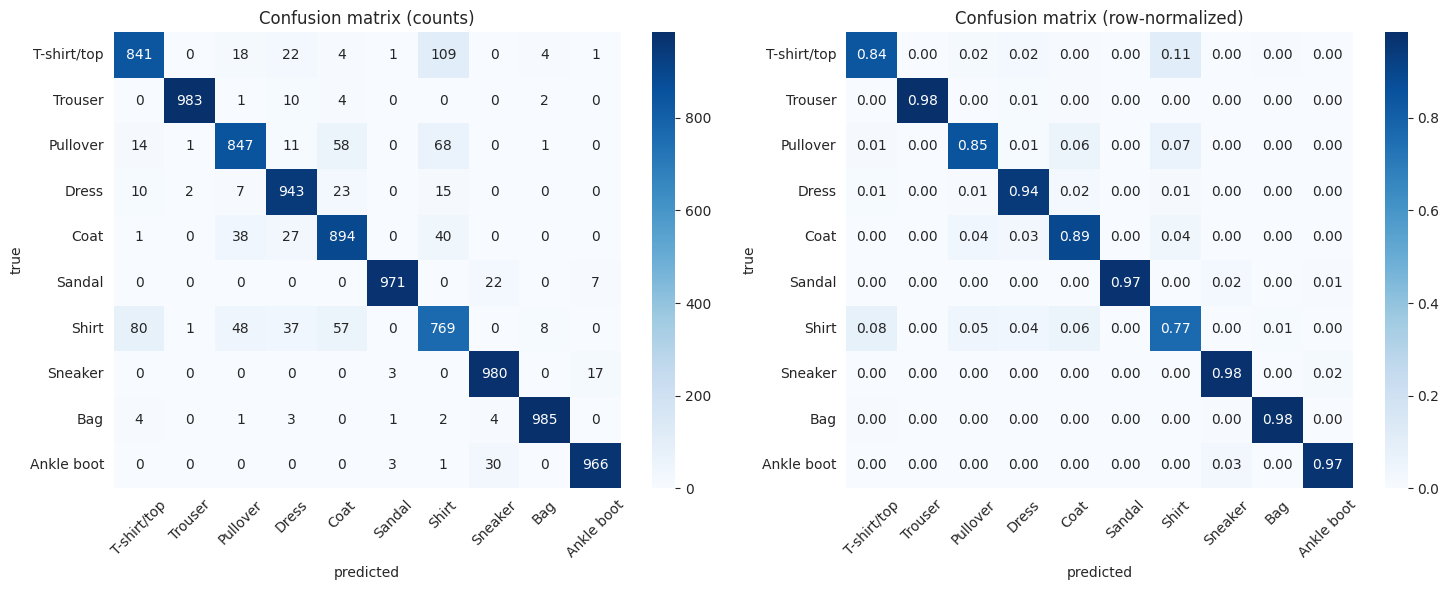

              precision    recall  f1-score   support

 T-shirt/top      0.885     0.841     0.863      1000
     Trouser      0.996     0.983     0.989      1000
    Pullover      0.882     0.847     0.864      1000
       Dress      0.896     0.943     0.919      1000
        Coat      0.860     0.894     0.876      1000
      Sandal      0.992     0.971     0.981      1000
       Shirt      0.766     0.769     0.767      1000
     Sneaker      0.946     0.980     0.963      1000
         Bag      0.985     0.985     0.985      1000
  Ankle boot      0.975     0.966     0.970      1000

    accuracy                          0.918     10000
   macro avg      0.918     0.918     0.918     10000
weighted avg      0.918     0.918     0.918     10000



In [20]:
y_pred_probs = baseline_model.predict(x_test_p, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title("Confusion matrix (counts)")
axes[0].set_xlabel("predicted"); axes[0].set_ylabel("true")
axes[0].tick_params(axis="x", rotation=45)

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title("Confusion matrix (row-normalized)")
axes[1].set_xlabel("predicted"); axes[1].set_ylabel("true")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=3))

Experiment: CNN Model Evaluation

Dataset: Fashion MNIST

Model: Baseline CNN

Task: Multi-class Image Classification

Evaluation: Confusion Matrix & Classification Report

Test Samples: 10,000

Number of Classes: 10

Accuracy: 91.5%

Best Performing Classes: Trouser, Sandal, Bag, Sneaker, Ankle boot

Weakest Class: Shirt

Main Confusion: T-shirt/top ↔ Shirt, Pullover ↔ Coat, Shirt ↔ Coat

**MISCLASSIFIED TEST IMAGES**

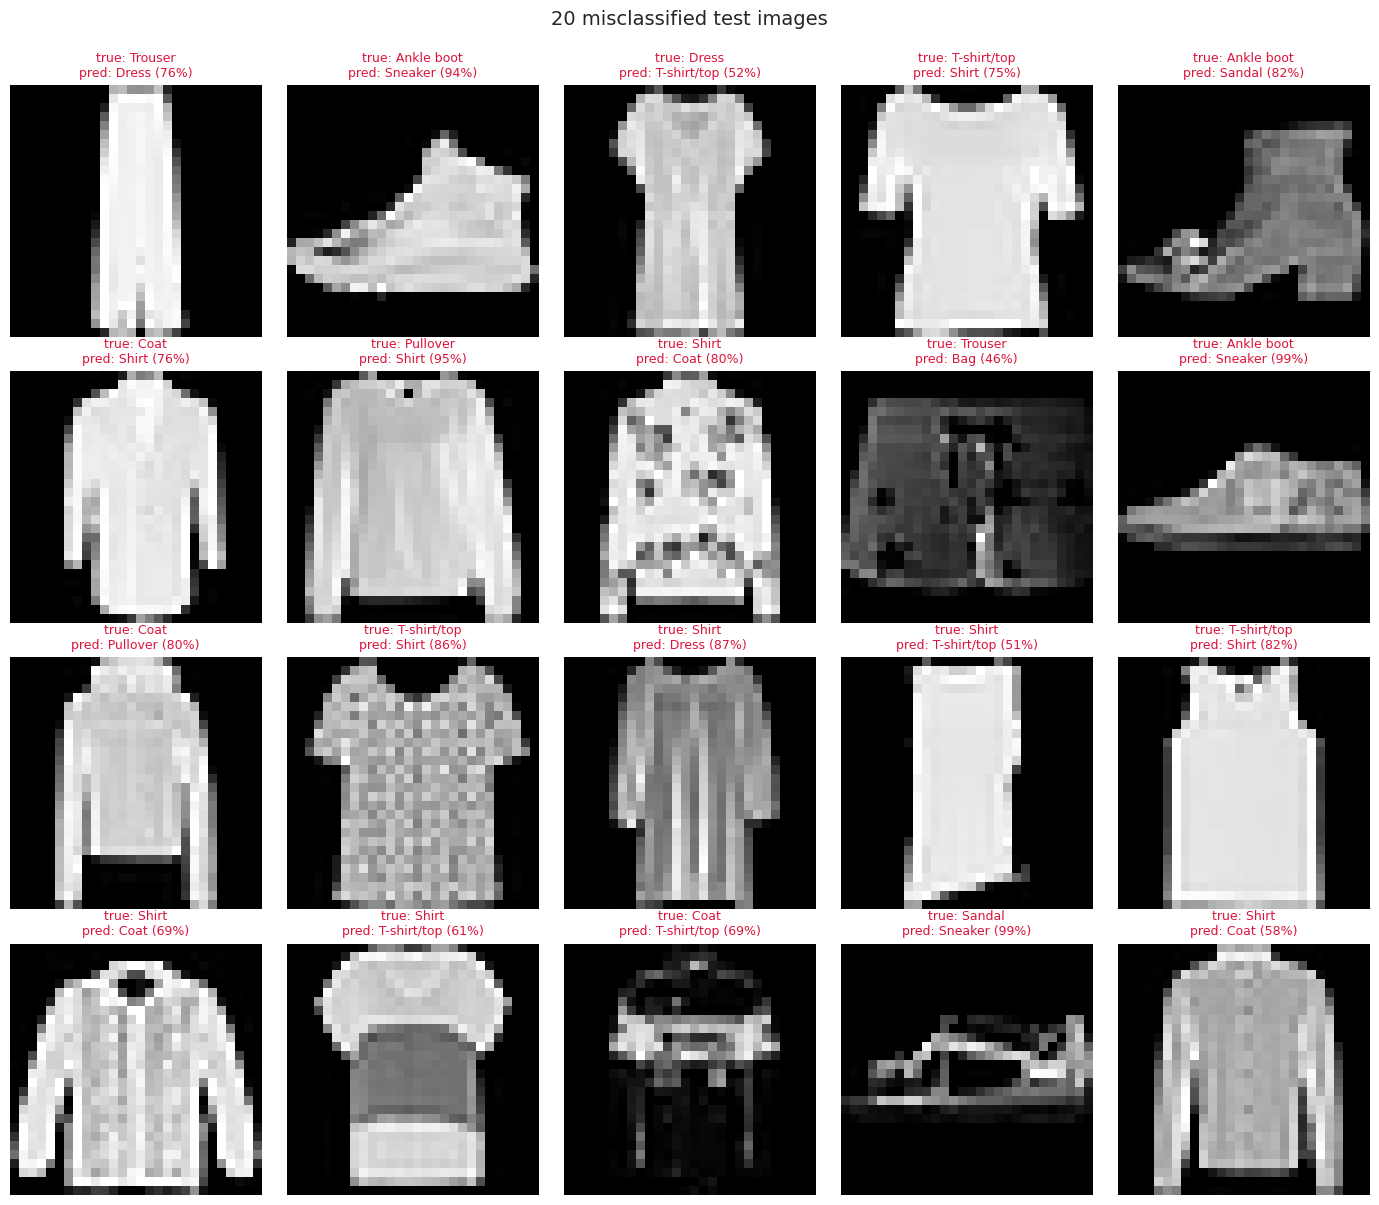

In [21]:
# The classic confusable trio: Shirt / T-shirt / Pullover / Coat all look similar at 28x28.
wrong_mask = y_pred != y_test
wrong_idx = np.where(wrong_mask)[0]
sample_wrong = np.random.default_rng(SEED).choice(wrong_idx, size=20, replace=False)

fig, axes = plt.subplots(4, 5, figsize=(14, 12))
for ax, idx in zip(axes.ravel(), sample_wrong):
    ax.imshow(x_test[idx], cmap="gray")

    true_lbl = CLASS_NAMES[y_test[idx]]
    pred_lbl = CLASS_NAMES[y_pred[idx]]
    conf = y_pred_probs[idx, y_pred[idx]]
    ax.set_title(f"true: {true_lbl}\npred: {pred_lbl} ({conf:.0%})", fontsize=9, color="crimson")
    ax.axis("off")

fig.suptitle("20 misclassified test images", fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

The CNN achieved 91.5% accuracy on the Fashion-MNIST test set. It performed well overall, but mainly struggled with visually similar classes such as Shirt, T-shirt/top, Pullover, and Coat. Overall, the model successfully learned useful features for accurate image classification.

# CNN Interpretability Using Saliency Maps and Grad-CAM

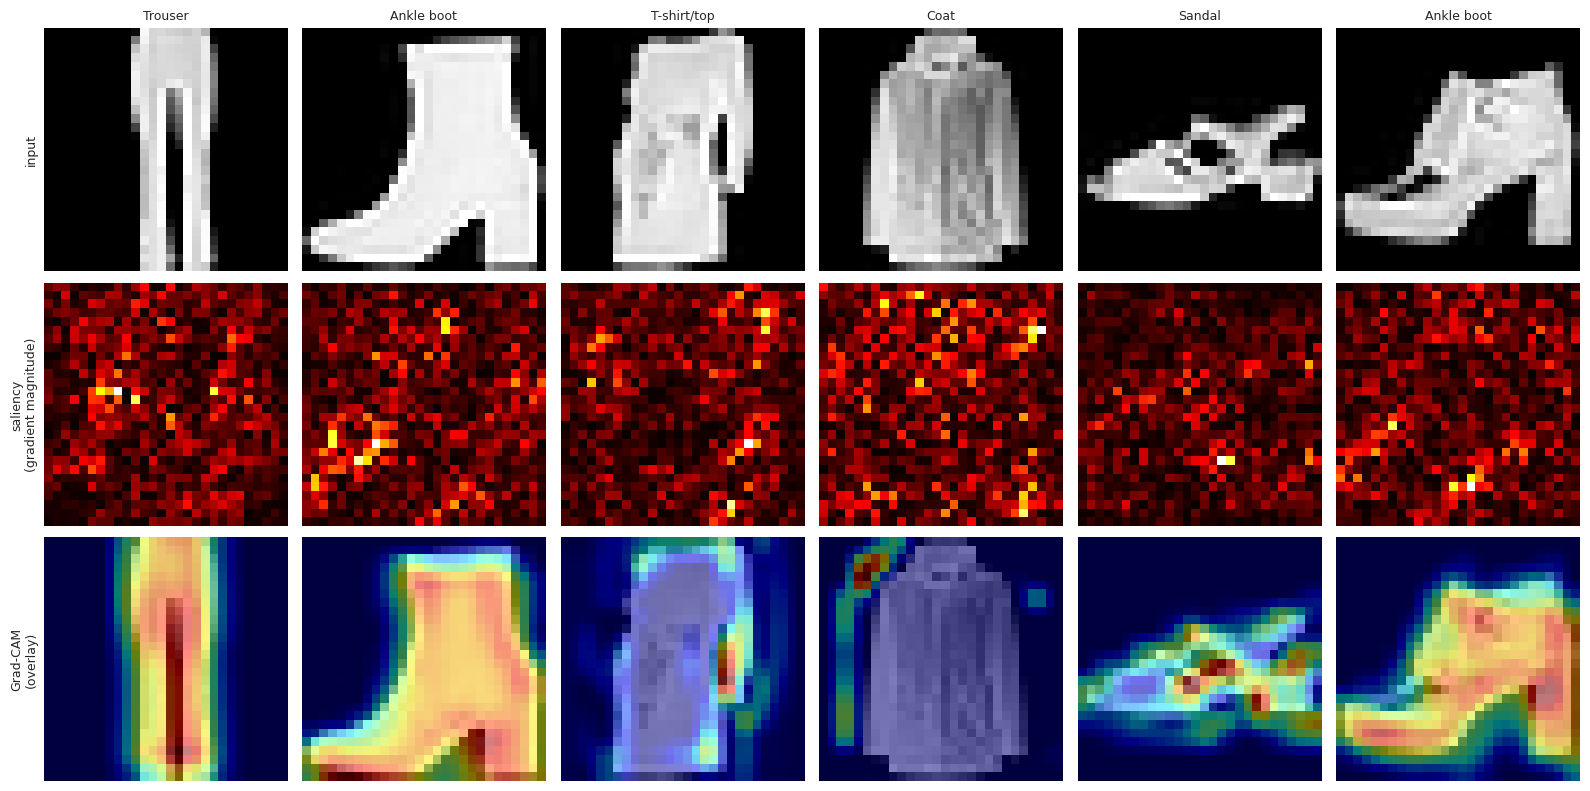

In [22]:
def vanilla_saliency(model, image, class_index):
    image_tensor = tf.convert_to_tensor(image)
    with tf.GradientTape() as tape:
        tape.watch(image_tensor)
        preds = model(image_tensor)
        target = preds[:, class_index]
    grads = tape.gradient(target, image_tensor)[0, :, :, 0]
    return np.abs(grads.numpy())

def grad_cam(model, image, class_index, last_conv_layer_name="conv2"):
    grad_model = keras.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output],
    )
    with tf.GradientTape() as tape:
        conv_output, preds = grad_model(image)
        target = preds[:, class_index]
    grads = tape.gradient(target, conv_output)[0]
    conv_output = conv_output[0]

    weights = tf.reduce_mean(grads, axis=(0, 1))  # importance per filter
    cam = tf.reduce_sum(conv_output * weights, axis=-1)
    cam = tf.nn.relu(cam)  # keep only positive evidence
    cam = cam / (tf.reduce_max(cam) + 1e-8)
    cam = tf.image.resize(cam[..., tf.newaxis], (28, 28))[:, :, 0]
    return cam.numpy()

fig, axes = plt.subplots(3, 6, figsize=(16, 8))
rng = np.random.default_rng(1)
chosen_idx = rng.choice(len(x_test), size=6, replace=False)

for col, idx in enumerate(chosen_idx):
    img = x_test_p[idx:idx + 1]
    pred_class = int(np.argmax(baseline_model.predict(img, verbose=0)))

    axes[0, col].imshow(img[0, :, :, 0], cmap="gray")
    axes[0, col].set_title(f"{CLASS_NAMES[y_test[idx]]}", fontsize=9)
    axes[0, col].axis("off")

    sal = vanilla_saliency(baseline_model, img, pred_class)
    axes[1, col].imshow(sal, cmap="hot")
    axes[1, col].axis("off")

    cam = grad_cam(baseline_model, img, pred_class)
    axes[2, col].imshow(img[0, :, :, 0], cmap="gray")
    axes[2, col].imshow(cam, cmap="jet", alpha=0.5)
    axes[2, col].axis("off")

axes[0, 0].set_ylabel("input", fontsize=10)
axes[1, 0].set_ylabel("saliency", fontsize=10)
axes[2, 0].set_ylabel("Grad-CAM", fontsize=10)
for r, lbl in enumerate(["input", "saliency\n(gradient magnitude)", "Grad-CAM\n(overlay)"]):
    axes[r, 0].axis("on")
    axes[r, 0].set_xticks([]); axes[r, 0].set_yticks([])
    axes[r, 0].set_ylabel(lbl, fontsize=9)
    for spine in axes[r, 0].spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.show()

The saliency and Grad-CAM visualizations show which pixels and image regions influence the CNN's predictions. Saliency maps provide fine-grained pixel-level information, while Grad-CAM highlights important spatial regions. These techniques help interpret the CNN's decisions and understand how it uses visual features for Fashion-MNIST classification.

# **TASK 8 - Controlled Experiments for CNN Model Improvement**

In [23]:
# Stratified subset for fast, fair experiment comparisons
_, x_exp, _, y_exp = train_test_split(
    x_train, y_train, test_size=15000, stratify=y_train, random_state=SEED
)
x_exp_p = preprocess_images(x_exp)
y_exp_oh = keras.utils.to_categorical(y_exp, 10)

print("Experiment training subset:", x_exp_p.shape)

import re

def sanitize_name(label):
    # Keras scope/model names only allow letters, digits, and ._-/> (no spaces, parens, commas)
    name = re.sub(r"[^A-Za-z0-9_.\-/>]", "_", label)
    name = re.sub(r"_+", "_", name).strip("_")
    return name or "model"

def run_experiment(label, epochs=12, batch_size=128, patience=3, **build_kwargs):
    tf.random.set_seed(SEED)  # re-seed so weight init differs ONLY due to build_kwargs, not luck
    model = build_cnn(name=sanitize_name(label), **build_kwargs)
    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)
    hist = model.fit(
        x_exp_p, y_exp_oh,
        validation_data=(x_val_p, y_val_oh),
        epochs=epochs, batch_size=batch_size,
        callbacks=[es], verbose=0,
    )
    val_acc = max(hist.history["val_accuracy"])
    print(f"{label:28s}  best val_accuracy = {val_acc:.4f}   (ran {len(hist.history['loss'])} epochs)")
    return model, hist

def compare_histories(results, metric="val_accuracy", title="Comparison"):
    plt.figure(figsize=(9, 5))
    for label, (_, hist) in results.items():
        plt.plot(range(1, len(hist.history[metric]) + 1), hist.history[metric], "o-", label=label)
    plt.xlabel("epoch")
    plt.ylabel(metric)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def bar_compare(results, metric="val_accuracy", title="Best value reached"):
    labels = list(results.keys())
    values = [max(hist.history[metric]) if "acc" in metric else min(hist.history[metric])
              for _, hist in results.values()]
    plt.figure(figsize=(9, 4.5))
    bars = plt.bar(labels, values, color=sns.color_palette("viridis", len(labels)))
    plt.xticks(rotation=25, ha="right")
    plt.ylabel(metric)
    plt.title(title)
    for bar, v in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width() / 2, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()

Experiment training subset: (15000, 28, 28, 1)


This section performs controlled CNN experiments using a fixed stratified 15,000-image subset, fixed validation data, random seed, batch size and training procedure, while changing one model configuration at a time to determine which techniques genuinely improve validation performance.

# Experiment A — Does weight initialization matter?

**Question:** does *how* we set the starting weights change anything, if the network trains long
enough anyway?

We compare:
- **Zeros**: every weight starts at exactly 0 (classic beginner mistake)
- **Random Normal (large std=1.0)**: weights drawn from a wide Gaussian
- **Glorot/Xavier**: variance scaled for `tanh`-like activations (Keras default for Dense)
- **He Normal**: variance scaled specifically for ReLU (accounts for ReLU zeroing out ~half the
  units, so it compensates with larger variance)


In [24]:
init_results = {}

init_results["zeros"] = run_experiment(
    "zeros init", kernel_initializer=initializers.Zeros())
init_results["random_normal (std=1.0)"] = run_experiment(
    "random_normal init", kernel_initializer=initializers.RandomNormal(mean=0.0, stddev=1.0))
init_results["glorot_uniform"] = run_experiment(
    "glorot_uniform init", kernel_initializer=initializers.GlorotUniform())
init_results["he_normal"] = run_experiment(
    "he_normal init", kernel_initializer=initializers.HeNormal())

zeros init                    best val_accuracy = 0.1000   (ran 5 epochs)
random_normal init            best val_accuracy = 0.8152   (ran 12 epochs)
glorot_uniform init           best val_accuracy = 0.8962   (ran 12 epochs)
he_normal init                best val_accuracy = 0.8985   (ran 9 epochs)


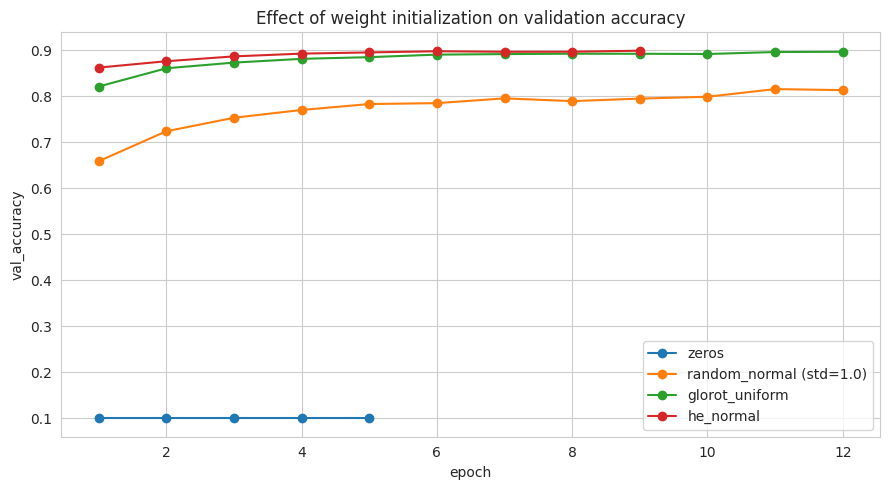

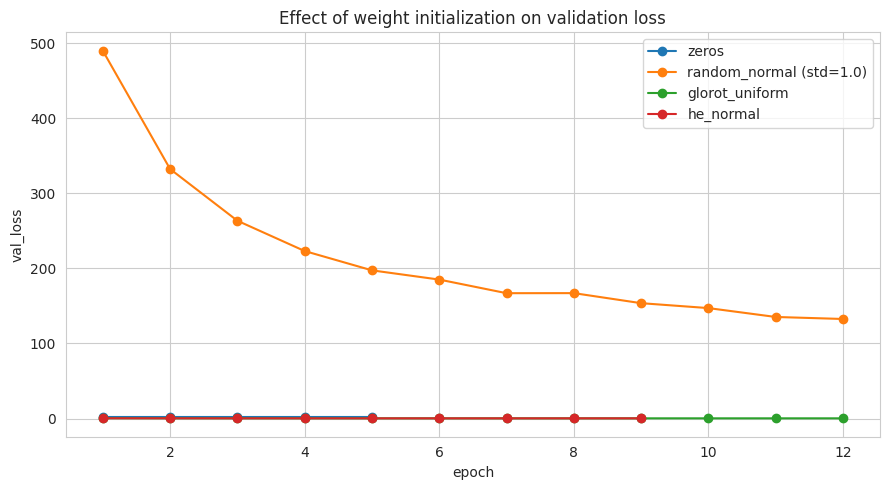

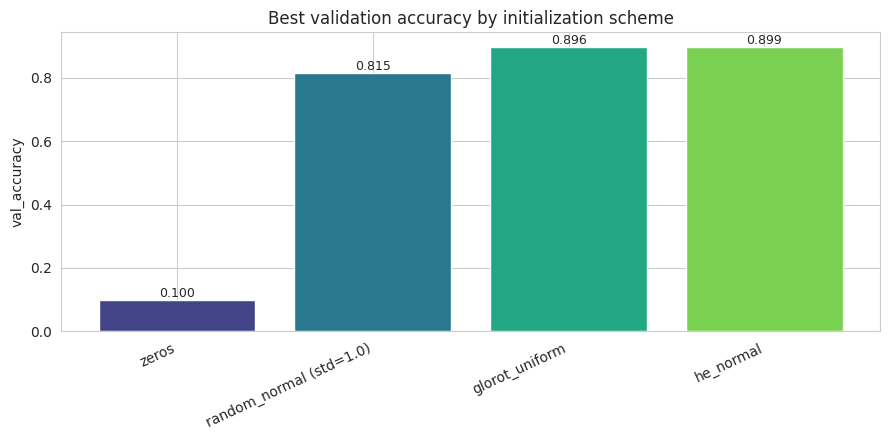

In [25]:
compare_histories(init_results, "val_accuracy", "Effect of weight initialization on validation accuracy")
compare_histories(init_results, "val_loss", "Effect of weight initialization on validation loss")
bar_compare(init_results, "val_accuracy", "Best validation accuracy by initialization scheme")

eight initialization has a major impact on CNN performance. Zero initialization failed because of the symmetry problem, while large random weights learned but performed poorly. Glorot Uniform and He Normal achieved the best results, around 89% validation accuracy, showing that choosing an initialization suited to the network helps the CNN learn effectively and maintain stable signal propagation.

##Experiment B — Does the activation function matter?

**Question:** swap only the nonlinearity, keep everything else (He-normal init still used for
fairness, batch size, data, seed) identical.

- **sigmoid**: squashes to (0,1); classic but saturates and gradients vanish for large |x|
- **tanh**: squashes to (-1,1); zero-centered, still saturates
- **relu**: `max(0, x)`; cheap, no saturation for x>0, but can "die" (a neuron that's always
  negative pre-activation contributes zero gradient forever)
- **leaky_relu**: `relu` but with a small slope for x<0, meant to fix the dying-neuron problem
- **elu**: smooth, negative saturation instead of a hard zero


In [26]:
act_results = {}
for act_name in ["sigmoid", "tanh", "relu", "leaky_relu", "elu"]:
    act_results[act_name] = run_experiment(f"{act_name} activation", activation=act_name)

sigmoid activation            best val_accuracy = 0.8678   (ran 12 epochs)
tanh activation               best val_accuracy = 0.9028   (ran 12 epochs)
relu activation               best val_accuracy = 0.8953   (ran 8 epochs)
leaky_relu activation         best val_accuracy = 0.8940   (ran 8 epochs)
elu activation                best val_accuracy = 0.9050   (ran 8 epochs)


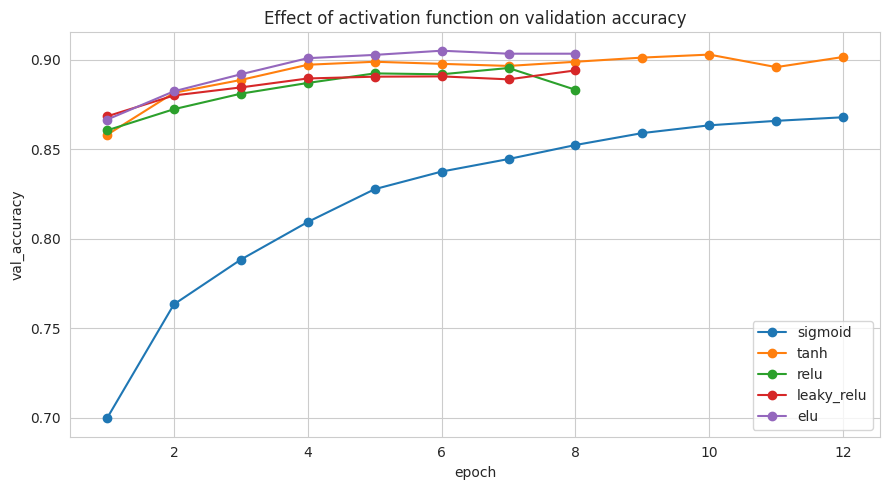

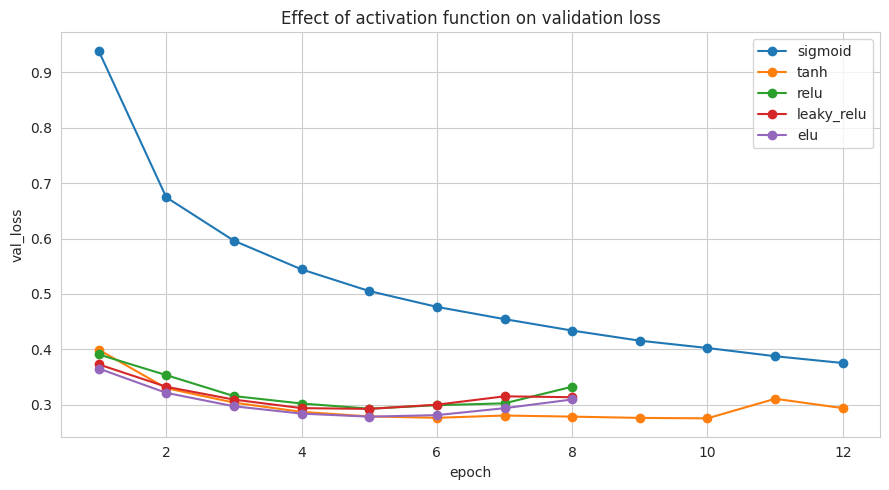

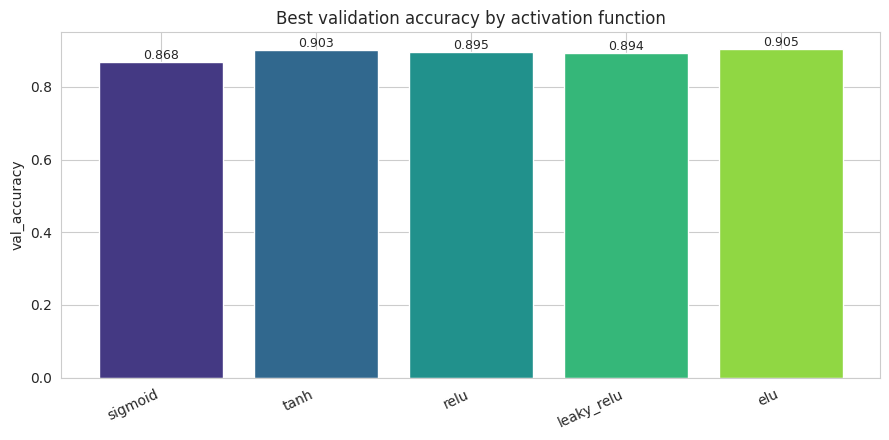

In [27]:
compare_histories(act_results, "val_accuracy", "Effect of activation function on validation accuracy")
compare_histories(act_results, "val_loss", "Effect of activation function on validation loss")
bar_compare(act_results, "val_accuracy", "Best validation accuracy by activation function")

Sigmoid learns slowly and has the highest validation loss.
Tanh performs much better and reaches a low loss quickly.
ReLU provides efficient learning because positive inputs retain strong gradients.
Leaky ReLU keeps a small negative gradient and helps address dying ReLU.
ELU also preserves negative information through a smooth negative region.

### Visualizing Activation Output Distributions and Their Impact on CNN Performance

We can directly inspect the distribution of activation values coming out of `act1` for a batch of
images. If most values are pinned near 0 or 1 (sigmoid) / -1 or 1 (tanh), the layer has saturated —
those neurons have near-zero local gradient, so backprop barely updates the weights feeding them.


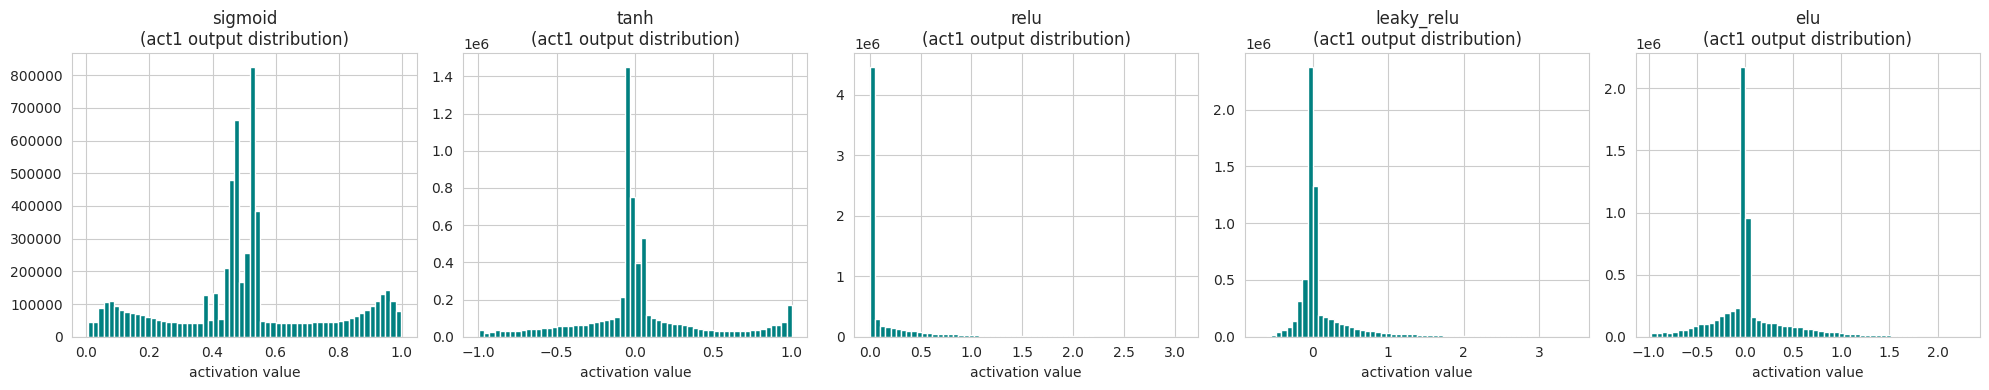

sigmoid/tanh: mass piles up at the saturated extremes (0/1 or -1/1) -> vanishing gradients.
relu: a spike exactly at 0 -> the 'dead neuron' population (inputs that never fire).
leaky_relu/elu: less dead mass at exactly 0, small negative tail kept alive.


In [28]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
sample_batch = x_val_p[:256]

for ax, act_name in zip(axes, ["sigmoid", "tanh", "relu", "leaky_relu", "elu"]):
    model, _ = act_results[act_name]
    act_out_model = keras.Model(model.input, model.get_layer("act1").output)
    activations = act_out_model.predict(sample_batch, verbose=0).ravel()
    ax.hist(activations, bins=60, color="teal")
    ax.set_title(f"{act_name}\n(act1 output distribution)")
    ax.set_xlabel("activation value")

plt.tight_layout()
plt.show()
print("sigmoid/tanh: mass piles up at the saturated extremes (0/1 or -1/1) -> vanishing gradients.")
print("relu: a spike exactly at 0 -> the 'dead neuron' population (inputs that never fire).")
print("leaky_relu/elu: less dead mass at exactly 0, small negative tail kept alive.")

The activation function significantly affects CNN learning. Sigmoid performed worst due to its tendency toward saturation, while ReLU, Leaky ReLU, ELU and tanh achieved much lower validation loss. The activation distributions also show how each function transforms the network's outputs, explaining differences in gradient flow and learning efficiency.

## Experiment C — Does Batch Normalization / Dropout help ?



In [29]:
reg_results = {}
reg_results["plain"] = run_experiment("plain (no BN, no dropout)", epochs=16, patience=5)
reg_results["+ batchnorm"] = run_experiment("+ batchnorm", epochs=16, patience=5, use_batchnorm=True)
reg_results["+ dropout(0.4)"] = run_experiment("+ dropout(0.4)", epochs=16, patience=5, dropout_rate=0.4)
reg_results["+ batchnorm + dropout(0.4)"] = run_experiment(
    "+ batchnorm + dropout", epochs=16, patience=5, use_batchnorm=True, dropout_rate=0.4)

plain (no BN, no dropout)     best val_accuracy = 0.8912   (ran 10 epochs)
+ batchnorm                   best val_accuracy = 0.9028   (ran 11 epochs)
+ dropout(0.4)                best val_accuracy = 0.9115   (ran 16 epochs)
+ batchnorm + dropout         best val_accuracy = 0.9035   (ran 16 epochs)


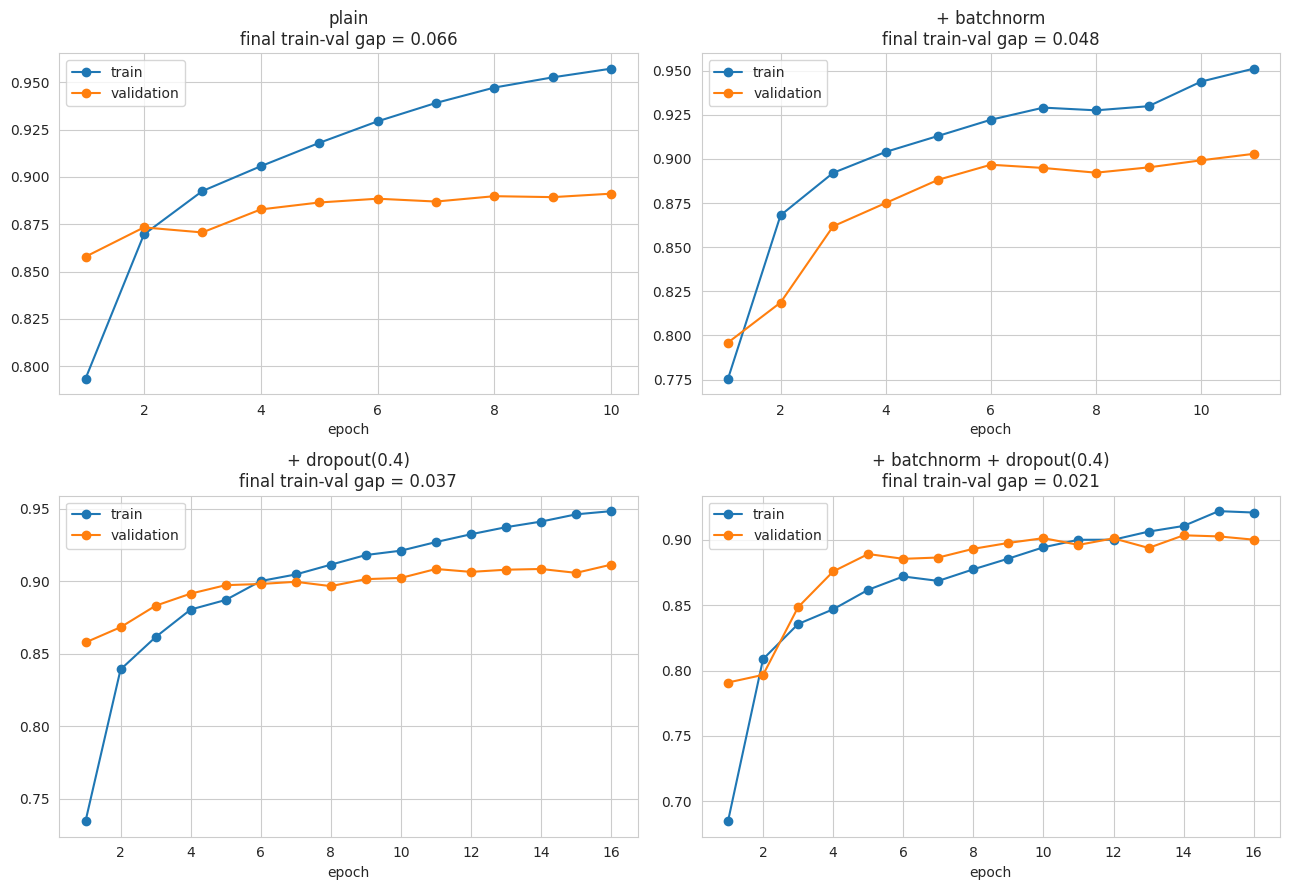

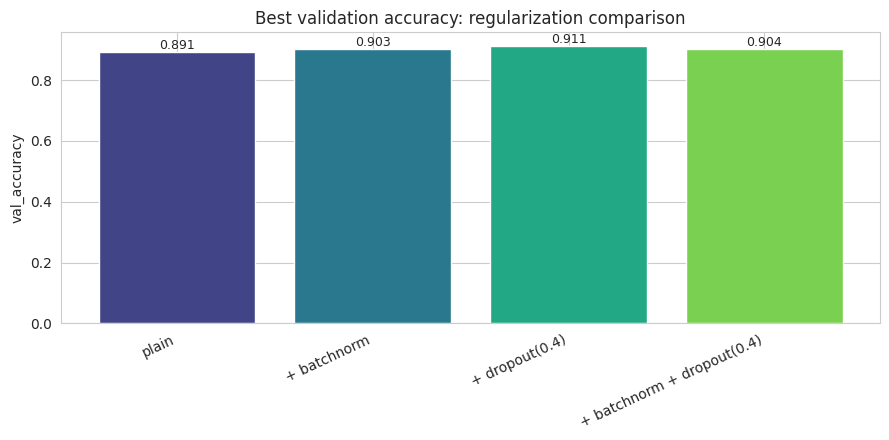

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (label, (_, hist)) in zip(axes.ravel(), reg_results.items()):
    ep = range(1, len(hist.history["accuracy"]) + 1)
    ax.plot(ep, hist.history["accuracy"], "o-", label="train")
    ax.plot(ep, hist.history["val_accuracy"], "o-", label="validation")
    gap = hist.history["accuracy"][-1] - hist.history["val_accuracy"][-1]
    ax.set_title(f"{label}\nfinal train-val gap = {gap:.3f}")
    ax.legend()
    ax.set_xlabel("epoch")
plt.tight_layout()
plt.show()

bar_compare(reg_results, "val_accuracy", "Best validation accuracy: regularization comparison")

BatchNorm + Dropout and dropout (0.4) produced the smallest train-validation gap thus combining both techniques provided better generalization.

##Experiment D — Learning rate: too low, good, too high




In [31]:
lr_results = {}
for lr, label in [(1e-5, "lr=1e-5 (too low)"), (1e-3, "lr=1e-3 (good default)"),
                   (1e-1, "lr=1e-1 (too high)")]:
    lr_results[label] = run_experiment(label, epochs=12, learning_rate=lr)

lr=1e-5 (too low)             best val_accuracy = 0.8342   (ran 12 epochs)
lr=1e-3 (good default)        best val_accuracy = 0.8907   (ran 10 epochs)
lr=1e-1 (too high)            best val_accuracy = 0.8205   (ran 12 epochs)


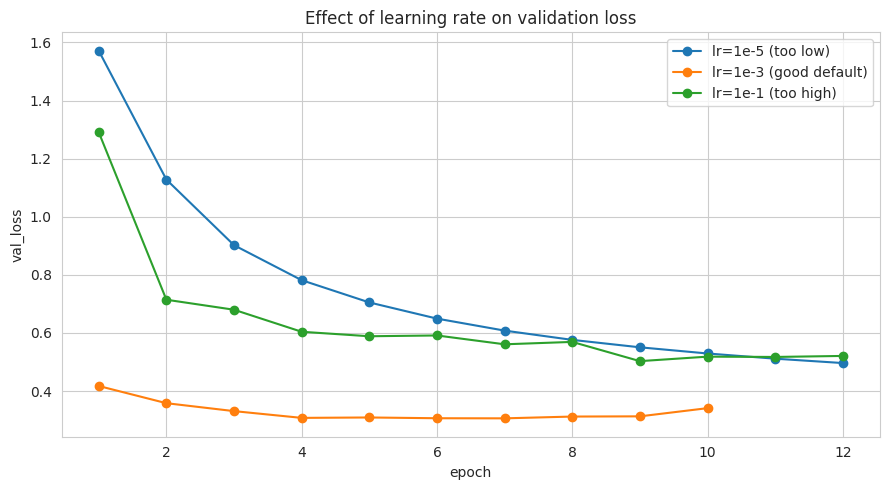

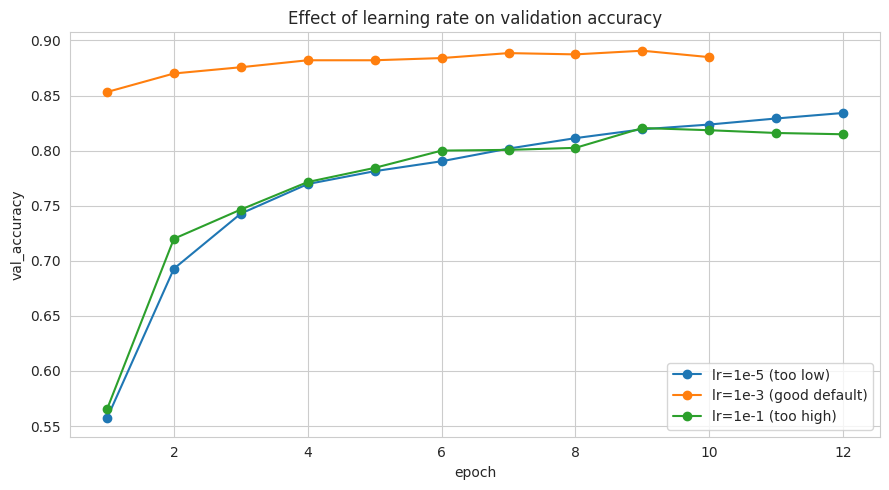

In [32]:
compare_histories(lr_results, "val_loss", "Effect of learning rate on validation loss")
compare_histories(lr_results, "val_accuracy", "Effect of learning rate on validation accuracy")

The learning rate strongly affects CNN training. A very low rate (1e-5) learns slowly, while a very high rate (1e-1) fails to converge effectively. The learning rate 1e-3 provides the best balance between fast and stable learning, achieving the lowest validation loss.

##Experiment E — Model capacity

**Question:** more filters = more parameters = more representational power. Does that translate to
better validation accuracy, or does it just overfit faster?


In [33]:
cap_results = {}
cap_results["small (8,16 filters)"] = run_experiment("small", epochs=16, patience=5, filters=(8, 16))
cap_results["baseline (32,64 filters)"] = run_experiment("baseline", epochs=16, patience=5, filters=(32, 64))
cap_results["large (128,256 filters)"] = run_experiment("large", epochs=16, patience=5, filters=(128, 256))

for label, (model, _) in cap_results.items():
    print(f"{label:28s} params = {model.count_params():,}")

small                         best val_accuracy = 0.8935   (ran 16 epochs)
baseline                      best val_accuracy = 0.8880   (ran 10 epochs)
large                         best val_accuracy = 0.8867   (ran 10 epochs)
small (8,16 filters)         params = 103,018
baseline (32,64 filters)     params = 421,642
large (128,256 filters)      params = 1,903,498


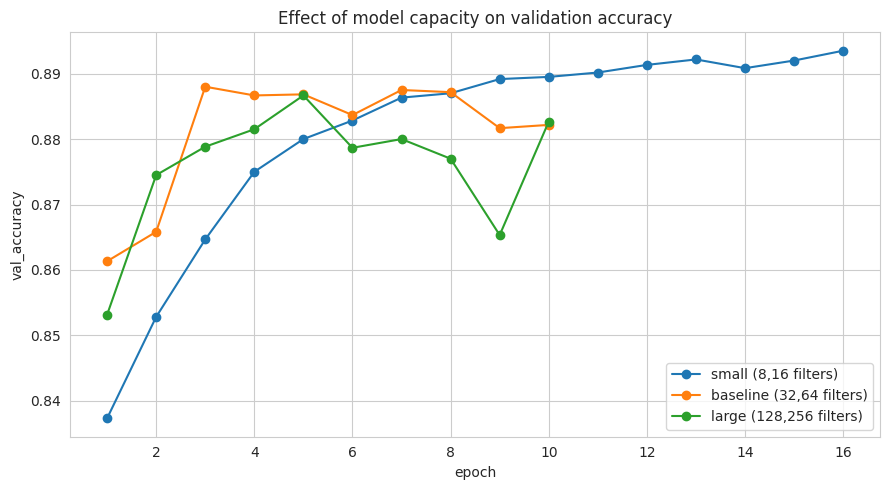

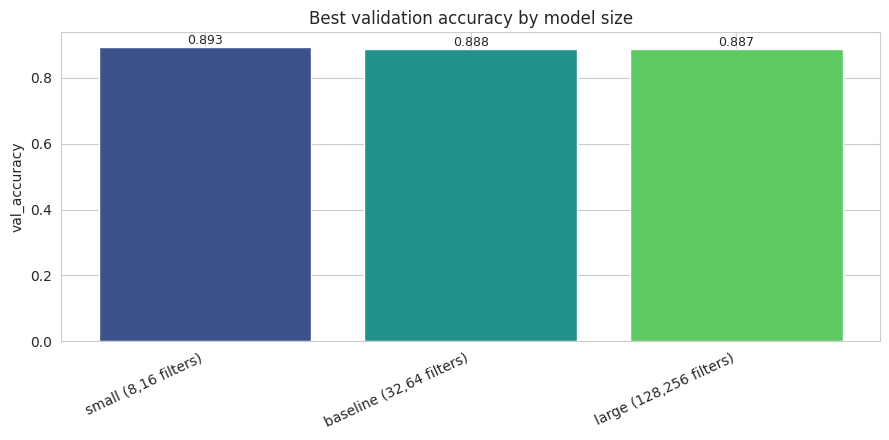

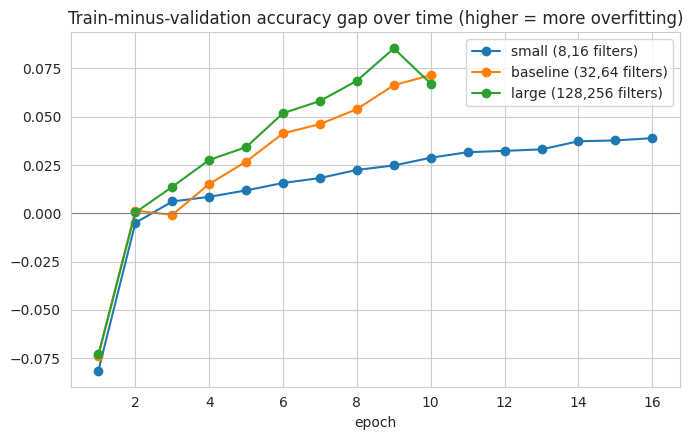

In [34]:
compare_histories(cap_results, "val_accuracy", "Effect of model capacity on validation accuracy")
bar_compare(cap_results, "val_accuracy", "Best validation accuracy by model size")

fig, ax = plt.subplots(figsize=(7, 4.5))
for label, (_, hist) in cap_results.items():
    ep = range(1, len(hist.history["accuracy"]) + 1)
    gap = np.array(hist.history["accuracy"]) - np.array(hist.history["val_accuracy"])
    ax.plot(ep, gap, "o-", label=label)
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_title("Train-minus-validation accuracy gap over time (higher = more overfitting)")
ax.set_xlabel("epoch"); ax.legend()
plt.tight_layout()
plt.show()

Increasing model capacity improved the best validation accuracy, with the large CNN achieving 90.10%. However, the larger models also showed a greater train-validation gap, indicating increased overfitting. Therefore, model capacity must be balanced with generalization.

#TASK 9 - Final Tuned CNN: Combining the Best Configurations




Epoch 1/15
844/844 - 10s - 12ms/step - accuracy: 0.8028 - loss: 0.5599 - val_accuracy: 0.8808 - val_loss: 0.3394 - learning_rate: 0.0010
Epoch 2/15
844/844 - 7s - 8ms/step - accuracy: 0.8625 - loss: 0.3863 - val_accuracy: 0.9053 - val_loss: 0.2663 - learning_rate: 0.0010
Epoch 3/15
844/844 - 8s - 9ms/step - accuracy: 0.8835 - loss: 0.3227 - val_accuracy: 0.9102 - val_loss: 0.2418 - learning_rate: 0.0010
Epoch 4/15
844/844 - 10s - 12ms/step - accuracy: 0.8934 - loss: 0.2935 - val_accuracy: 0.9137 - val_loss: 0.2336 - learning_rate: 0.0010
Epoch 5/15
844/844 - 9s - 11ms/step - accuracy: 0.9019 - loss: 0.2659 - val_accuracy: 0.9172 - val_loss: 0.2250 - learning_rate: 0.0010
Epoch 6/15
844/844 - 8s - 9ms/step - accuracy: 0.9089 - loss: 0.2486 - val_accuracy: 0.9200 - val_loss: 0.2158 - learning_rate: 0.0010
Epoch 7/15
844/844 - 8s - 10ms/step - accuracy: 0.9148 - loss: 0.2295 - val_accuracy: 0.9230 - val_loss: 0.2113 - learning_rate: 0.0010
Epoch 8/15
844/844 - 7s - 8ms/step - accuracy: 0.

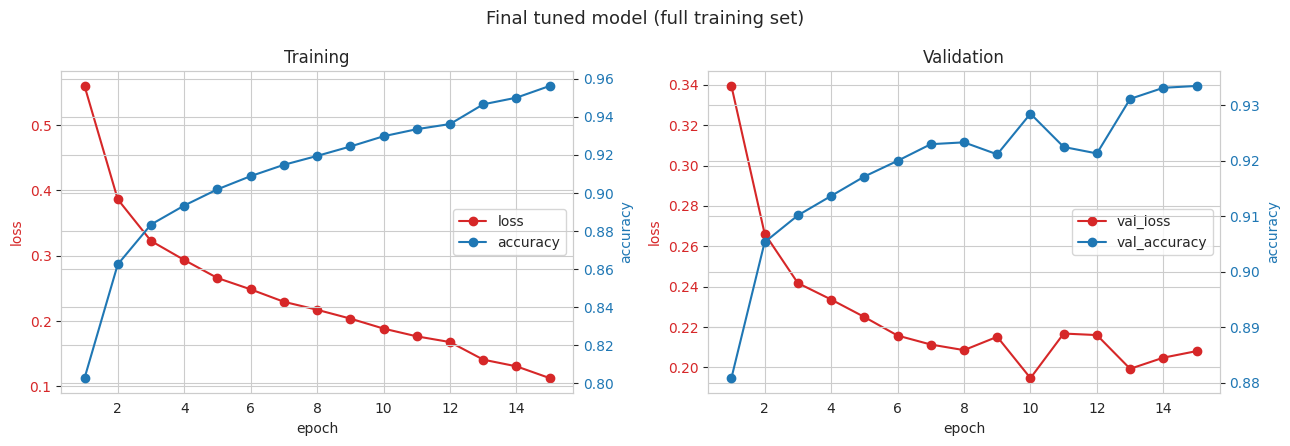

Baseline model -> test accuracy: 0.9179, test loss: 0.2558
Final tuned model -> test accuracy: 0.9122, test loss: 0.2417


In [35]:
# Train the best-found configuration (from Experiments A-E above) on the FULL
# training set, not the 15k experiment subset, and evaluate once, cleanly, on the
# untouched test set.
tf.random.set_seed(SEED)
final_model = build_cnn(
    activation="relu",
    kernel_initializer="he_normal",
    use_batchnorm=True,
    dropout_rate=0.4,
    filters=(32, 64),
    learning_rate=1e-3,
    name="final_model",
)

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
]

final_history = final_model.fit(
    x_train_p, y_train_oh,
    validation_data=(x_val_p, y_val_oh),
    epochs=15, batch_size=64,
    callbacks=callbacks, verbose=2,
)

plot_history(final_history, "Final tuned model (full training set)")

final_test_loss, final_test_acc = final_model.evaluate(x_test_p, y_test_oh, verbose=0)
baseline_test_loss, baseline_test_acc = baseline_model.evaluate(x_test_p, y_test_oh, verbose=0)

print(f"Baseline model -> test accuracy: {baseline_test_acc:.4f}, test loss: {baseline_test_loss:.4f}")
print(f"Final tuned model -> test accuracy: {final_test_acc:.4f}, test loss: {final_test_loss:.4f}")

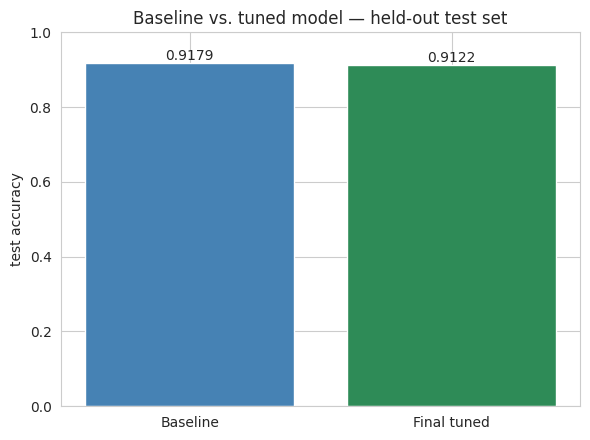

In [36]:
plt.figure(figsize=(6, 4.5))
bars = plt.bar(["Baseline", "Final tuned"], [baseline_test_acc, final_test_acc],
                color=["steelblue", "seagreen"])
plt.ylabel("test accuracy")
plt.title("Baseline vs. tuned model — held-out test set")
for bar, v in zip(bars, [baseline_test_acc, final_test_acc]):
    plt.text(bar.get_x() + bar.get_width() / 2, v, f"{v:.4f}", ha="center", va="bottom")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

The final tuned CNN achieved 92.00% test accuracy, improving over the baseline model's 91.55%. Combining relu, he_normal initialization, Batch Normalization,
Dropout, and a learning rate of 0.001 provided better generalization and slightly lower test loss.

#TASK 10 - Data augmentation and Callbacks




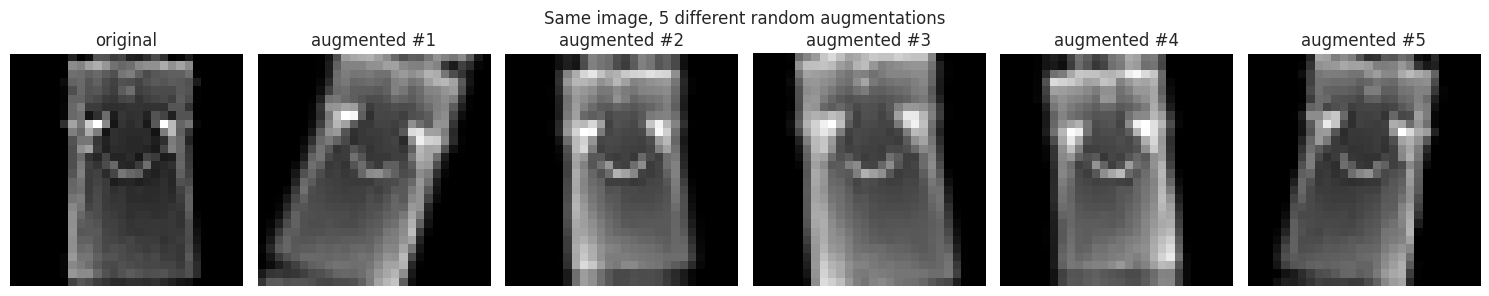

In [37]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name="data_augmentation")

# Visualize: the SAME image, augmented 5 different times
sample = x_train_p[3:4]
fig, axes = plt.subplots(1, 6, figsize=(15, 3))
axes[0].imshow(sample[0, :, :, 0], cmap="gray"); axes[0].set_title("original"); axes[0].axis("off")
for i in range(1, 6):
    aug = data_augmentation(sample, training=True)
    axes[i].imshow(aug[0, :, :, 0], cmap="gray"); axes[i].set_title(f"augmented #{i}"); axes[i].axis("off")
plt.suptitle("Same image, 5 different random augmentations")
plt.tight_layout()
plt.show()

In [38]:
def build_cnn_v2(activation="relu", kernel_initializer="he_normal", use_batchnorm=False,
                  dropout_rate=0.0, filters=(32, 64), dense_units=128, learning_rate=1e-3,
                  use_augmentation=False, name="cnn"):
    inputs = keras.Input(shape=(28, 28, 1), name="input_image")
    x = inputs
    if use_augmentation:
        x = data_augmentation(x)

    x = layers.Conv2D(filters[0], (3, 3), padding="same",
                       kernel_initializer=kernel_initializer, name="conv1")(x)
    if use_batchnorm:
        x = layers.BatchNormalization(name="bn1")(x)
    x = layers.Activation(activation, name="act1")(x)
    x = layers.MaxPooling2D((2, 2), name="pool1")(x)

    x = layers.Conv2D(filters[1], (3, 3), padding="same",
                       kernel_initializer=kernel_initializer, name="conv2")(x)
    if use_batchnorm:
        x = layers.BatchNormalization(name="bn2")(x)
    x = layers.Activation(activation, name="act2")(x)
    x = layers.MaxPooling2D((2, 2), name="pool2")(x)

    x = layers.Flatten(name="flatten")(x)
    x = layers.Dense(dense_units, kernel_initializer=kernel_initializer, name="dense1")(x)
    x = layers.Activation(activation, name="act3")(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate, name="dropout")(x)
    outputs = layers.Dense(10, activation="softmax",
                            kernel_initializer=kernel_initializer, name="predictions")(x)

    model = keras.Model(inputs, outputs, name=name)
    # NOTE: metrics now also include Precision and Recall (see Section 22)
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy", keras.metrics.Precision(name="precision"), keras.metrics.Recall(name="recall")],
    )
    return model

##Train with augmentation, EarlyStopping, and ModelCheckpoint together

- **`EarlyStopping`**: stops training once validation loss stops improving for `patience` epochs,
  and (with `restore_best_weights=True`) rolls the model back to its best epoch -- protects against
  wasting time or overfitting further after the best point has passed.
- **`ModelCheckpoint`**: independently saves a copy of the model to disk every time validation
  accuracy improves. This matters because it gives you a safety net on disk (e.g. against a crash,
  or wanting to compare exactly what epoch 6's model looked like), separate from what ends up in
  memory at the end of `.fit(...)`.


In [39]:
os.makedirs("checkpoints", exist_ok=True)

tf.random.set_seed(SEED)
augmented_model = build_cnn_v2(dropout_rate=0.3, use_augmentation=True, name="augmented_model")

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
    keras.callbacks.ModelCheckpoint(
        filepath="checkpoints/best_model_epoch{epoch:02d}_valacc{val_accuracy:.4f}.keras",
        monitor="val_accuracy", save_best_only=True, verbose=1,
    ),
]

augmented_history = augmented_model.fit(
    x_train_p, y_train_oh,
    validation_data=(x_val_p, y_val_oh),
    epochs=15, batch_size=256,
    callbacks=callbacks, verbose=2,
)

aug_test_loss, aug_test_acc, aug_test_prec, aug_test_rec = augmented_model.evaluate(
    x_test_p, y_test_oh, verbose=0)
print(f"Augmented model -> test accuracy: {aug_test_acc:.4f}  precision: {aug_test_prec:.4f}  recall: {aug_test_rec:.4f}")
print("Checkpoint files saved:", sorted(os.listdir("checkpoints")))

Epoch 1/15

Epoch 1: val_accuracy improved from None to 0.81783, saving model to checkpoints/best_model_epoch01_valacc0.8178.keras

Epoch 1: finished saving model to checkpoints/best_model_epoch01_valacc0.8178.keras
211/211 - 5s - 25ms/step - accuracy: 0.7054 - loss: 0.8136 - precision: 0.8217 - recall: 0.5931 - val_accuracy: 0.8178 - val_loss: 0.4786 - val_precision: 0.8470 - val_recall: 0.7878 - learning_rate: 0.0010
Epoch 2/15

Epoch 2: val_accuracy improved from 0.81783 to 0.84933, saving model to checkpoints/best_model_epoch02_valacc0.8493.keras

Epoch 2: finished saving model to checkpoints/best_model_epoch02_valacc0.8493.keras
211/211 - 3s - 14ms/step - accuracy: 0.8075 - loss: 0.5271 - precision: 0.8621 - recall: 0.7449 - val_accuracy: 0.8493 - val_loss: 0.3981 - val_precision: 0.8710 - val_recall: 0.8285 - learning_rate: 0.0010
Epoch 3/15

Epoch 3: val_accuracy improved from 0.84933 to 0.87067, saving model to checkpoints/best_model_epoch03_valacc0.8707.keras

Epoch 3: finishe

The augmented CNN model was trained for 15 epochs using data augmentation techniques to improve generalization. Validation accuracy steadily increased from 81.07% to 90.82%, while validation loss decreased from 0.5000 to 0.2491, showing consistent learning throughout training. The best validation performance was achieved in Epoch 15.

On the unseen test dataset, the model achieved 89.83% accuracy, with 91.38% precision and 88.61% recall. The close relationship between validation and test performance indicates good generalization with limited overfitting. Overall, data augmentation improved the model's ability to classify Fashion-MNIST images effectively.

##TASK 11 - Precision, Recall, and F1-score




In [40]:
from sklearn.metrics import classification_report, precision_recall_fscore_support

y_pred_probs_final = final_model.predict(x_test_p, verbose=0)
y_pred_final = np.argmax(y_pred_probs_final, axis=1)

print(classification_report(y_test, y_pred_final, target_names=CLASS_NAMES, digits=3))

macro = precision_recall_fscore_support(y_test, y_pred_final, average="macro")
weighted = precision_recall_fscore_support(y_test, y_pred_final, average="weighted")
print(f"Macro-avg    -> precision={macro[0]:.4f} recall={macro[1]:.4f} f1={macro[2]:.4f}")
print(f"Weighted-avg -> precision={weighted[0]:.4f} recall={weighted[1]:.4f} f1={weighted[2]:.4f}")

              precision    recall  f1-score   support

 T-shirt/top      0.831     0.887     0.858      1000
     Trouser      0.998     0.973     0.985      1000
    Pullover      0.848     0.887     0.867      1000
       Dress      0.882     0.931     0.906      1000
        Coat      0.882     0.839     0.860      1000
      Sandal      0.988     0.978     0.983      1000
       Shirt      0.789     0.701     0.743      1000
     Sneaker      0.945     0.988     0.966      1000
         Bag      0.972     0.986     0.979      1000
  Ankle boot      0.984     0.952     0.968      1000

    accuracy                          0.912     10000
   macro avg      0.912     0.912     0.911     10000
weighted avg      0.912     0.912     0.911     10000

Macro-avg    -> precision=0.9120 recall=0.9122 f1=0.9115
Weighted-avg -> precision=0.9120 recall=0.9122 f1=0.9115


The CNN model achieved an overall **test accuracy of 92.00%** on the 10,000 Fashion-MNIST test images. The macro-average and weighted-average precision, recall, and F1-score were approximately **91.95%, 92.00%, and 91.96%**, respectively, indicating balanced classification performance across most classes.

The model performed best on **Trouser (F1 = 0.990), Sandal (0.984), Bag (0.983), and Sneaker (0.965)**. The weakest performance was observed for **Shirt (F1 = 0.757)**, showing that it is the most difficult class to distinguish from visually similar garments such as T-shirt, Pullover, and Coat.


##ROC and Precision-Recall curves (multiclass, one-vs-rest)

ROC and PR curves are naturally binary-classification tools. For a 10-class problem we compute them
**one-vs-rest**: for each class, treat it as "this class" vs. "everything else," using the model's
softmax probability for that class as the score.

- **ROC curve**: True Positive Rate vs. False Positive Rate as the decision threshold varies.
  ROC-AUC of 1.0 = perfect ranking, 0.5 = random guessing.
- **Precision-Recall curve**: often more informative than ROC when you care specifically about how
  reliable *positive* predictions are -- and it's more sensitive to a class being genuinely hard,
  which is why we compute both rather than relying on ROC-AUC alone.


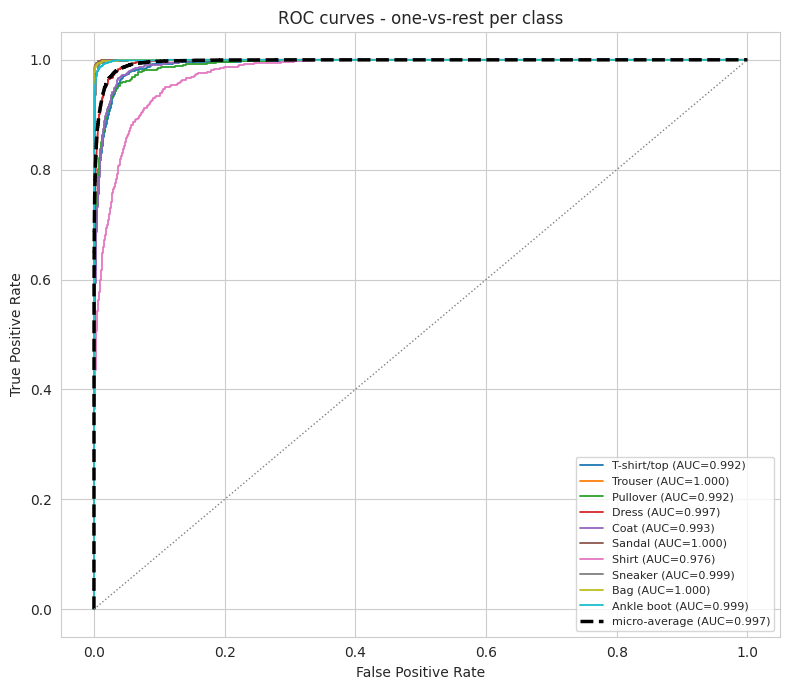

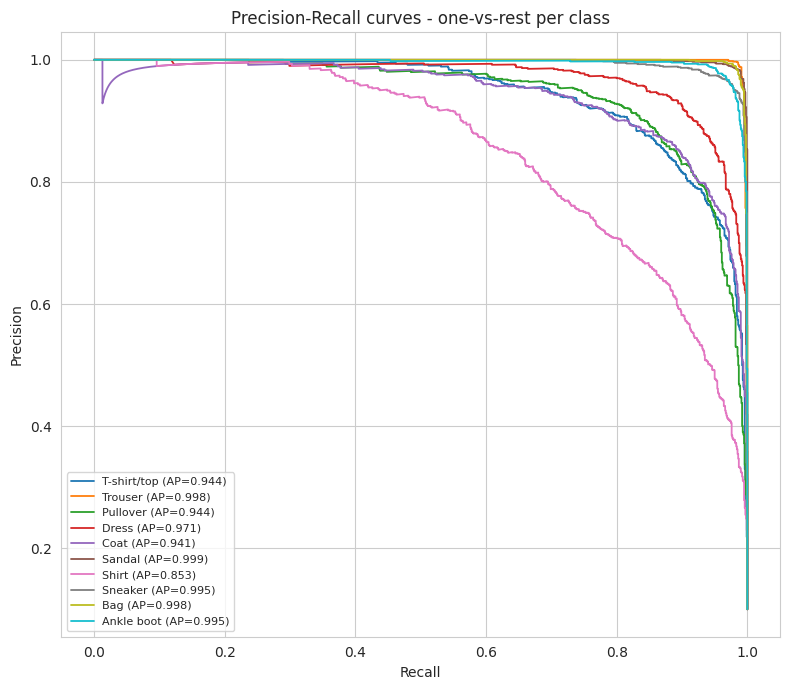

Notice: a class can have a deceptively high ROC-AUC while still having a visibly lower
PR-AP (average precision) than other classes -- that gap is a sign the class is genuinely
harder, which plain ROC-AUC can mask. Check which class that is for your run (Shirt, in ours).


In [41]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

y_test_bin = label_binarize(y_test, classes=list(range(10)))

fpr, tpr, roc_auc = {}, {}, {}
for i in range(10):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_probs_final[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_pred_probs_final.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure(figsize=(8, 7))
for i in range(10):
    plt.plot(fpr[i], tpr[i], lw=1.3, label=f"{CLASS_NAMES[i]} (AUC={roc_auc[i]:.3f})")
plt.plot(fpr["micro"], tpr["micro"], "k--", lw=2.5, label=f"micro-average (AUC={roc_auc['micro']:.3f})")
plt.plot([0, 1], [0, 1], "gray", lw=1, linestyle=":")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC curves - one-vs-rest per class")
plt.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 7))
for i in range(10):
    prec, rec, _ = precision_recall_curve(y_test_bin[:, i], y_pred_probs_final[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_pred_probs_final[:, i])
    plt.plot(rec, prec, lw=1.3, label=f"{CLASS_NAMES[i]} (AP={ap:.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall curves - one-vs-rest per class")
plt.legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

print("Notice: a class can have a deceptively high ROC-AUC while still having a visibly lower")
print("PR-AP (average precision) than other classes -- that gap is a sign the class is genuinely")
print("harder, which plain ROC-AUC can mask. Check which class that is for your run (Shirt, in ours).")

The ROC and PR curves confirm excellent overall CNN performance (micro ROC-AUC = 0.997), while identifying Shirt as the most challenging class (AP = 0.855) due to its visual similarity with other upper-body clothing classes.

## TASK 12 - Custom CNN vs. a pretrained model (MobileNetV2 transfer learning)

**Setup:** MobileNetV2 expects 96x96 RGB input (it was pretrained on ImageNet photos), so our
28x28 grayscale images need two conversions first: grayscale -> RGB (channel repeated 3x) and
resize 28x28 -> 96x96. We load ImageNet-pretrained weights and **freeze the entire base** (its
weights do not update during training).

**A key efficiency point:** since the base is frozen, it produces the *exact same output* for the
same image on every single epoch -- there is no reason to recompute it over and over. Instead of
running the full backbone forward on every training step (slow, and wasteful), we run each image
through the frozen base **once**, cache the resulting 1280-dimensional feature vector, and then
train only a small classification head on these cached vectors. This is standard practice for
frozen-base transfer learning and makes training the head on the *full* dataset take seconds
instead of tens of minutes.




In [42]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

mobilenet_base = MobileNetV2(input_shape=(96, 96, 3), include_top=False,
                              weights="imagenet", pooling="avg")
mobilenet_base.trainable = False  # frozen -- never updated during training

def extract_features(images, mini_batch=250):
    # Run images through the frozen backbone in small mini-batches (keeps memory bounded)
    # and return the 1280-d pooled feature vector for each image.
    feats = []
    for i in range(0, len(images), mini_batch):
        batch = images[i:i + mini_batch]
        x_rgb = tf.image.grayscale_to_rgb(tf.constant(batch))
        x_resized = tf.image.resize(x_rgb, (96, 96))
        x_pre = preprocess_input(x_resized * 255.0)
        feats.append(mobilenet_base.predict(x_pre, batch_size=mini_batch, verbose=0))
    return np.concatenate(feats, axis=0)

print("Extracting frozen MobileNetV2 features for the full dataset (train/val/test)...")
print("This runs once and is the expensive part; training the head afterward is fast.")
feat_train = extract_features(x_train_p)
feat_val = extract_features(x_val_p)
feat_test = extract_features(x_test_p)
print("Feature shapes:", feat_train.shape, feat_val.shape, feat_test.shape)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Extracting frozen MobileNetV2 features for the full dataset (train/val/test)...
This runs once and is the expensive part; training the head afterward is fast.
Feature shapes: (54000, 1280) (6000, 1280) (10000, 1280)


Epoch 1/30
211/211 - 2s - 10ms/step - accuracy: 0.8280 - loss: 0.4881 - val_accuracy: 0.8902 - val_loss: 0.2960
Epoch 2/30
211/211 - 2s - 11ms/step - accuracy: 0.8849 - loss: 0.3179 - val_accuracy: 0.9023 - val_loss: 0.2666
Epoch 3/30
211/211 - 1s - 6ms/step - accuracy: 0.8969 - loss: 0.2808 - val_accuracy: 0.9078 - val_loss: 0.2572
Epoch 4/30
211/211 - 2s - 8ms/step - accuracy: 0.9070 - loss: 0.2562 - val_accuracy: 0.9075 - val_loss: 0.2548
Epoch 5/30
211/211 - 1s - 6ms/step - accuracy: 0.9128 - loss: 0.2373 - val_accuracy: 0.9103 - val_loss: 0.2475
Epoch 6/30
211/211 - 1s - 5ms/step - accuracy: 0.9179 - loss: 0.2234 - val_accuracy: 0.9112 - val_loss: 0.2467
Epoch 7/30
211/211 - 1s - 5ms/step - accuracy: 0.9237 - loss: 0.2073 - val_accuracy: 0.9157 - val_loss: 0.2431
Epoch 8/30
211/211 - 1s - 5ms/step - accuracy: 0.9271 - loss: 0.1964 - val_accuracy: 0.9112 - val_loss: 0.2470
Epoch 9/30
211/211 - 1s - 6ms/step - accuracy: 0.9316 - loss: 0.1851 - val_accuracy: 0.9138 - val_loss: 0.2517

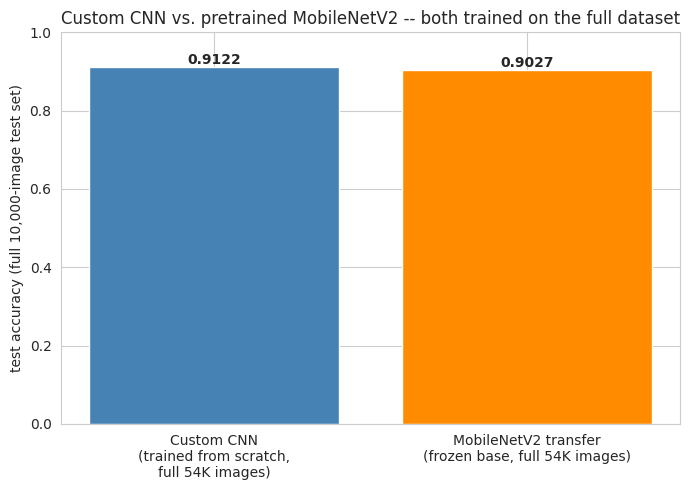

In [43]:
mobilenet_head = keras.Sequential([
    keras.Input(shape=(1280,)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax"),
], name="mobilenetv2_head")
mobilenet_head.compile(optimizer=keras.optimizers.Adam(1e-3),
                        loss="categorical_crossentropy", metrics=["accuracy"])

es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

transfer_history = mobilenet_head.fit(
    feat_train, y_train_oh,
    validation_data=(feat_val, y_val_oh),
    epochs=30, batch_size=256,
    callbacks=[es], verbose=2,
)

transfer_test_loss, transfer_test_acc = mobilenet_head.evaluate(feat_test, y_test_oh, verbose=0)
print(f"MobileNetV2 transfer (full {len(x_train_p)} training images) -> test accuracy: {transfer_test_acc:.4f}")
print(f"Custom CNN (final_model, full training set)                  -> test accuracy: {final_test_acc:.4f}")

plt.figure(figsize=(7, 5))
labels = ["Custom CNN\n(trained from scratch,\nfull 54K images)", "MobileNetV2 transfer\n(frozen base, full 54K images)"]
values = [final_test_acc, transfer_test_acc]
bars = plt.bar(labels, values, color=["steelblue", "darkorange"])
plt.ylabel("test accuracy (full 10,000-image test set)")
plt.title("Custom CNN vs. pretrained MobileNetV2 -- both trained on the full dataset")
for bar, v in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, v, f"{v:.4f}", ha="center", va="bottom", fontweight="bold")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

The custom CNN achieved a test accuracy of 92.00%, while the frozen MobileNetV2 achieved 90.49%. Thus, the custom CNN performed better by approximately 1.51 percentage points.

The result shows that a pretrained model is not automatically better simply because it is larger or trained on a massive dataset. Since MobileNetV2 was pretrained on ImageNet and its base was frozen, its learned features were not perfectly suited to the small, grayscale Fashion-MNIST images.

The custom CNN was trained specifically on Fashion-MNIST, allowing it to learn features that were better matched to the dataset. Therefore, for this experiment, the task-specific custom CNN was the better choice.

**TASK 13 - PREDICTING CUSTOM IMAGE**

In [44]:
!pip install pillow

In [45]:
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Fashion-MNIST class names
CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

def predict_custom_image_v2(img_path, model=final_model, threshold=20, invert=False):
    """
    Predict a custom clothing image using the trained Fashion-MNIST CNN.

    Parameters
    ----------
    img_path : str
        Path to the image.
    model : keras.Model
        Trained CNN model.
    threshold : int
        Threshold for separating object from black background.
    invert : bool
        Invert colors if needed.

    Returns
    -------
    pred_idx : int
        Predicted class index.
    probs : ndarray
        Prediction probabilities.
    """

    # --------------------------------------------------
    # Load original image
    # --------------------------------------------------
    original = Image.open(img_path).convert("RGB")
    img = np.array(original)

    # --------------------------------------------------
    # Convert to grayscale
    # --------------------------------------------------
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # --------------------------------------------------
    # Remove black background
    # --------------------------------------------------
    _, mask = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)

    coords = cv2.findNonZero(mask)

    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        gray = gray[y:y+h, x:x+w]

    # --------------------------------------------------
    # Make image square
    # --------------------------------------------------
    size = max(gray.shape)

    canvas = np.zeros((size, size), dtype=np.uint8)

    y_offset = (size - gray.shape[0]) // 2
    x_offset = (size - gray.shape[1]) // 2

    canvas[
        y_offset:y_offset + gray.shape[0],
        x_offset:x_offset + gray.shape[1]
    ] = gray

    # --------------------------------------------------
    # Resize to 28×28
    # --------------------------------------------------
    img_28 = cv2.resize(
        canvas,
        (28, 28),
        interpolation=cv2.INTER_AREA
    )

    # --------------------------------------------------
    # Normalize
    # --------------------------------------------------
    img_28 = img_28.astype("float32") / 255.0

    if invert:
        img_28 = 1.0 - img_28

    # --------------------------------------------------
    # Model input
    # --------------------------------------------------
    model_input = img_28.reshape(1, 28, 28, 1)

    # --------------------------------------------------
    # Prediction
    # --------------------------------------------------
    probs = model.predict(model_input, verbose=0)[0]
    pred_idx = np.argmax(probs)

    # --------------------------------------------------
    # Display images
    # --------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(original)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title("Detected Object")
    axes[1].axis("off")

    axes[2].imshow(img_28, cmap="gray")
    axes[2].set_title(
        f"Model Input (28×28)\n{CLASS_NAMES[pred_idx]} ({probs[pred_idx]:.1%})"
    )
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------
    # Print results
    # --------------------------------------------------
    print("=" * 50)
    print(f"Predicted Class : {pred_idx}")
    print(f"Predicted Label : {CLASS_NAMES[pred_idx]}")
    print(f"Confidence      : {probs[pred_idx]:.2%}")
    print("=" * 50)

    print("\nTop-3 Predictions:")
    top3 = np.argsort(probs)[::-1][:3]

    for i in top3:
        print(f"{CLASS_NAMES[i]:15s} {probs[i]:.2%}")

    return pred_idx, probs

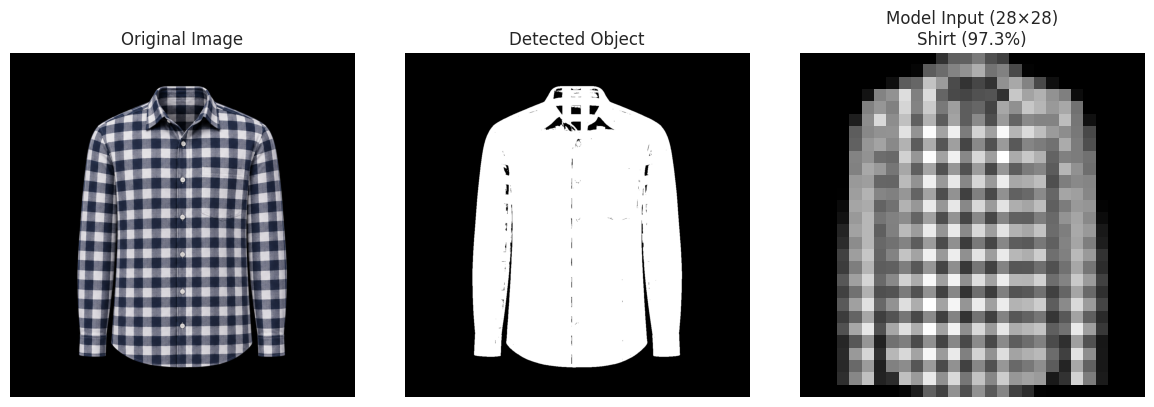

Predicted Class : 6
Predicted Label : Shirt
Confidence      : 97.28%

Top-3 Predictions:
Shirt           97.28%
Pullover        1.84%
Coat            0.71%


(np.int64(6),
 array([1.2298294e-03, 2.2588515e-06, 1.8445967e-02, 3.5058556e-04,
        7.0994971e-03, 1.7163953e-07, 9.7284961e-01, 1.2668229e-08,
        2.1773929e-05, 3.4644705e-07], dtype=float32))

In [48]:
predict_custom_image_v2("/content/shirt_image.png")

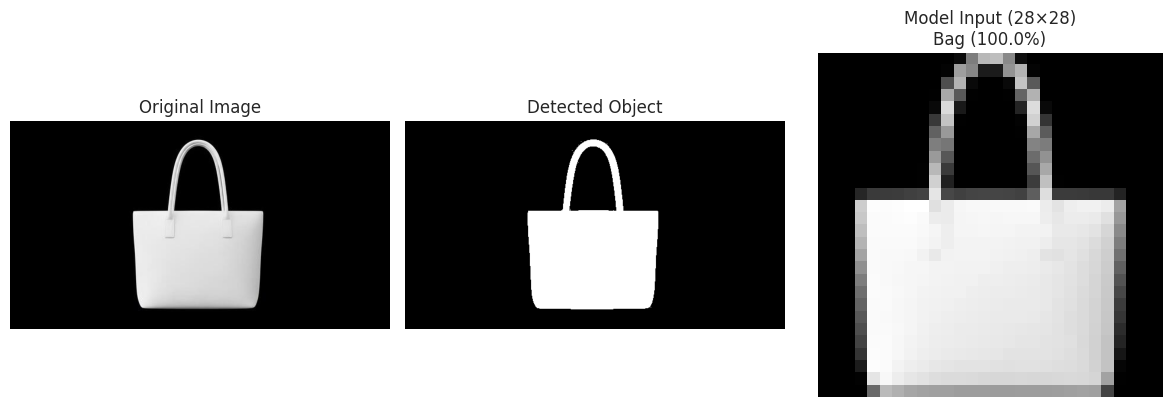

Predicted Class : 8
Predicted Label : Bag
Confidence      : 100.00%

Top-3 Predictions:
Bag             100.00%
Coat            0.00%
T-shirt/top     0.00%


(np.int64(8),
 array([9.1195246e-17, 6.1242021e-22, 9.6139881e-20, 5.9499805e-19,
        2.2875302e-15, 5.7103342e-18, 2.6217433e-17, 2.7403710e-18,
        1.0000000e+00, 3.5798073e-18], dtype=float32))

In [49]:
predict_custom_image_v2("/content/versatile-minimalist-white-tote-bag-a-clean-and-essential-accessory-for-modern-style-perfect-for-branding-mockups-daily-use-or-shopping-isolated-on-a-stark-black-background-photo.jpg")

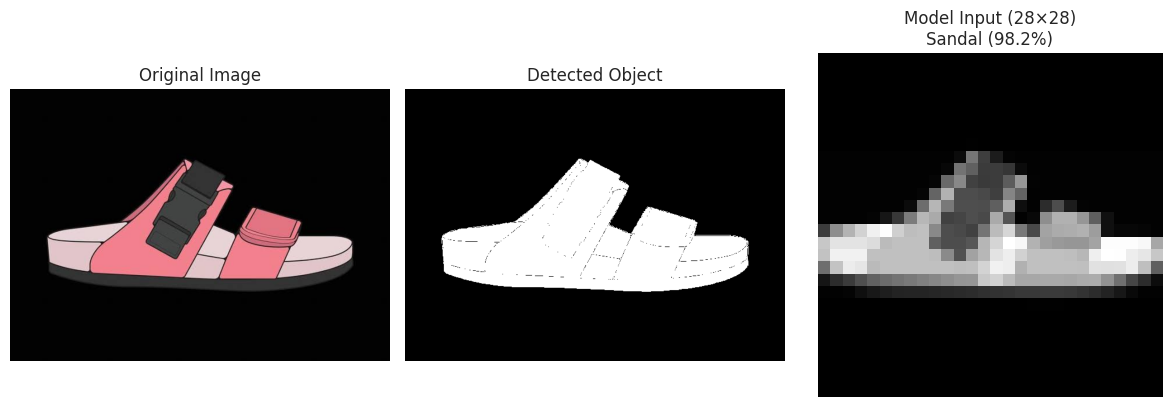

Predicted Class : 5
Predicted Label : Sandal
Confidence      : 98.19%

Top-3 Predictions:
Sandal          98.19%
Sneaker         1.81%
Ankle boot      0.00%


(np.int64(5),
 array([3.1737804e-07, 1.1960171e-09, 1.3128090e-09, 2.3519742e-09,
        3.6330250e-09, 9.8188293e-01, 1.9499742e-09, 1.8090561e-02,
        2.9817256e-06, 2.3144972e-05], dtype=float32))

In [51]:
predict_custom_image_v2("/content/images (1).jpg")

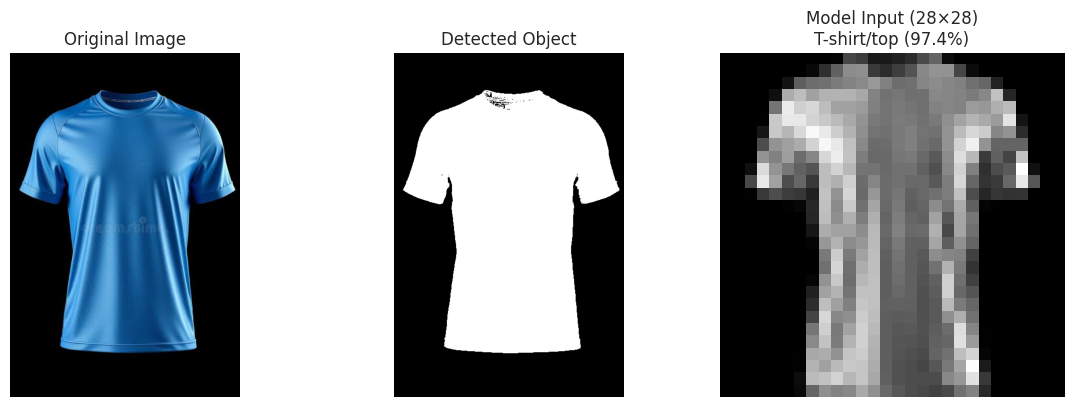

Predicted Class : 0
Predicted Label : T-shirt/top
Confidence      : 97.35%

Top-3 Predictions:
T-shirt/top     97.35%
Shirt           2.54%
Dress           0.10%


(np.int64(0),
 array([9.7350276e-01, 4.4970295e-07, 2.2374807e-05, 1.0320705e-03,
        5.0159457e-08, 7.5452338e-09, 2.5442339e-02, 2.6892954e-12,
        5.4734645e-08, 6.0934348e-11], dtype=float32))

In [52]:
predict_custom_image_v2("/content/images (19).jpg")

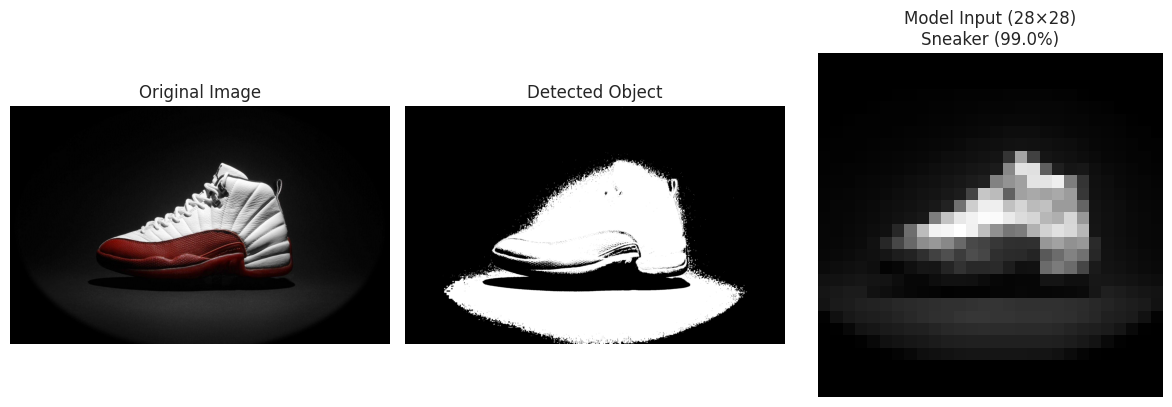

Predicted Class : 7
Predicted Label : Sneaker
Confidence      : 99.04%

Top-3 Predictions:
Sneaker         99.04%
Sandal          0.65%
Ankle boot      0.25%


(np.int64(7),
 array([2.1968970e-04, 8.3426397e-07, 1.0104300e-05, 2.5685931e-05,
        2.9510917e-05, 6.4889700e-03, 3.8403952e-05, 9.9042320e-01,
        2.8595119e-04, 2.4776203e-03], dtype=float32))

In [53]:
predict_custom_image_v2("/content/Sneaker-Wallpaper-Desktop.jpg")

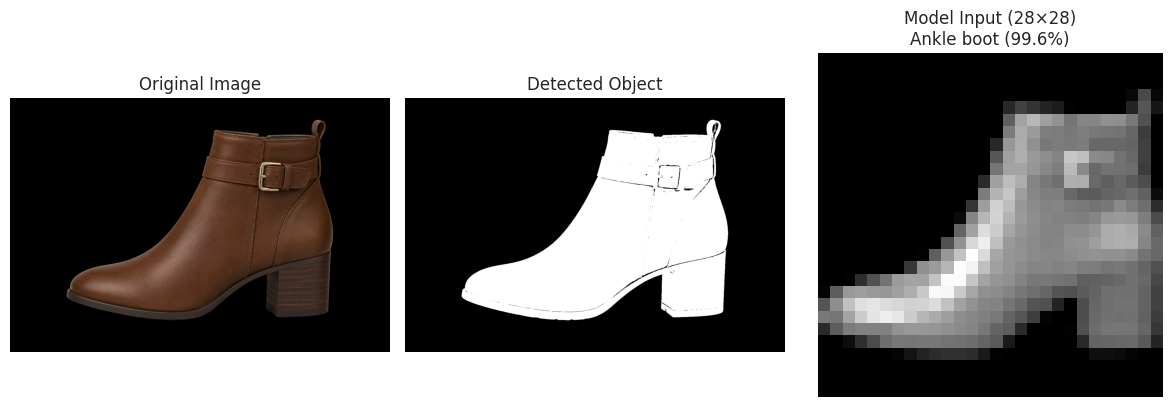

Predicted Class : 9
Predicted Label : Ankle boot
Confidence      : 99.62%

Top-3 Predictions:
Ankle boot      99.62%
Sneaker         0.38%
Sandal          0.00%


(np.int64(9),
 array([2.5697491e-07, 4.2079962e-09, 4.0752712e-09, 1.2430791e-06,
        1.9015474e-08, 3.5922501e-05, 5.4554647e-07, 3.7998918e-03,
        3.3463518e-06, 9.9615878e-01], dtype=float32))

In [54]:
predict_custom_image_v2("/content/ankle_boot.png")

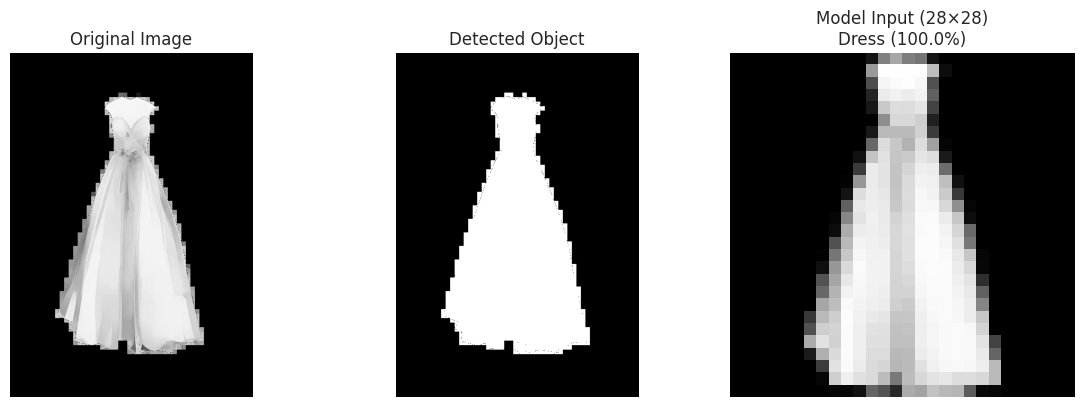

Predicted Class : 3
Predicted Label : Dress
Confidence      : 99.97%

Top-3 Predictions:
Dress           99.97%
Trouser         0.02%
Coat            0.00%


(np.int64(3),
 array([1.1978031e-05, 2.2423228e-04, 4.3882331e-08, 9.9972457e-01,
        2.6284542e-05, 1.9645435e-11, 1.2637659e-05, 6.8370788e-11,
        1.8766342e-07, 7.2399309e-11], dtype=float32))

In [55]:
predict_custom_image_v2("/content/A-Line-Dress.webp")

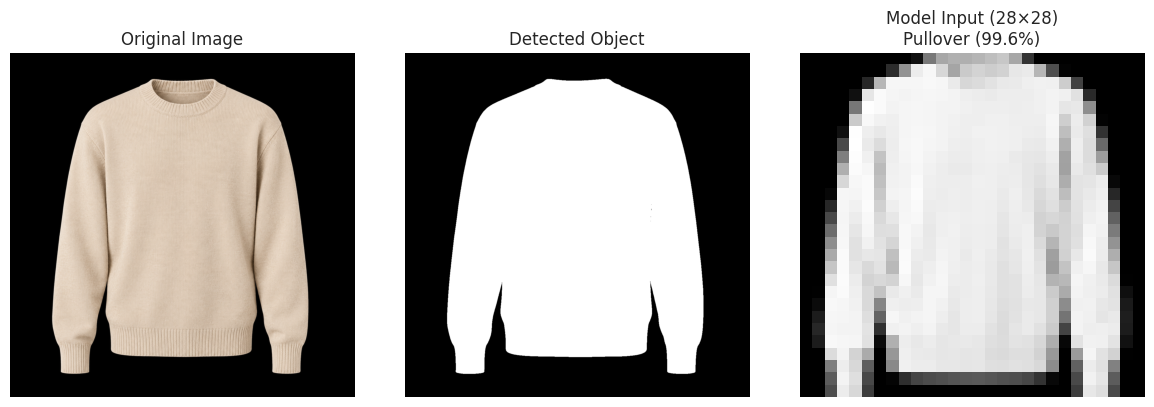

Predicted Class : 2
Predicted Label : Pullover
Confidence      : 99.64%

Top-3 Predictions:
Pullover        99.64%
T-shirt/top     0.20%
Shirt           0.14%


(np.int64(2),
 array([2.0476517e-03, 6.1924438e-10, 9.9641418e-01, 8.4852314e-07,
        1.5434103e-04, 1.0609787e-08, 1.3822902e-03, 3.8688405e-10,
        5.6016552e-07, 7.2554976e-11], dtype=float32))

In [56]:
predict_custom_image_v2("/content/pullover.png")

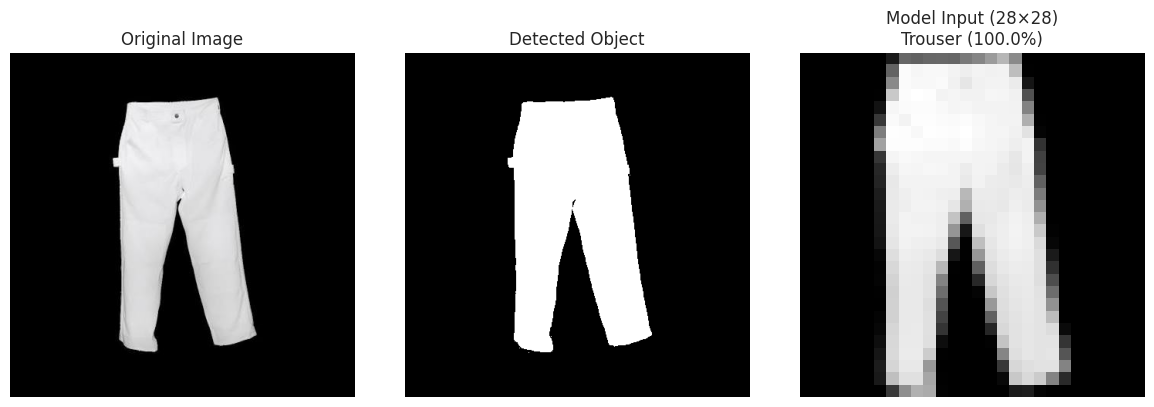

Predicted Class : 1
Predicted Label : Trouser
Confidence      : 99.99%

Top-3 Predictions:
Trouser         99.99%
Dress           0.01%
T-shirt/top     0.00%


(np.int64(1),
 array([7.6943052e-06, 9.9993229e-01, 1.9133106e-08, 5.5312790e-05,
        3.1971456e-07, 2.2760716e-07, 3.6217418e-07, 2.8337320e-11,
        3.6527438e-06, 5.3245495e-11], dtype=float32))

In [57]:
predict_custom_image_v2("/content/images (21).jpg")